#**SVC**

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [4]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,roc_curve,auc
from sklearn.model_selection import KFold

**Reading Dataset from drive**

In [5]:
data = pd.read_csv('/content/drive/My Drive/Sem5/new_ml/a3/spambase_csv.csv')
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


#**EDA**

**(i) Missing values**

In [6]:
data.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


**(ii) Handle Outliers**

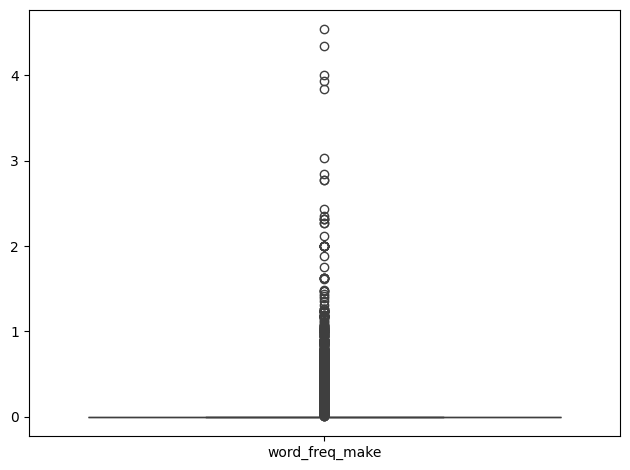

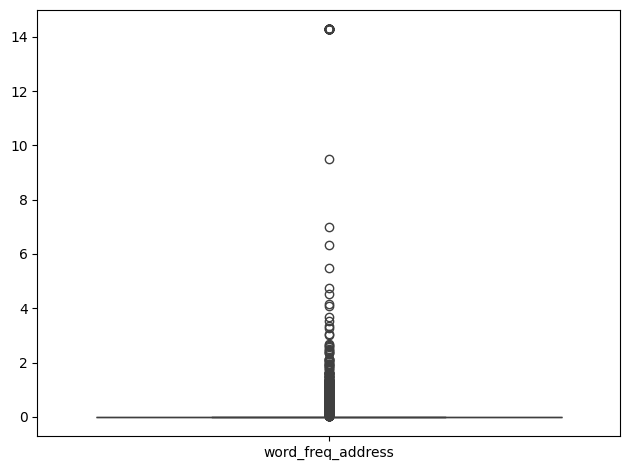

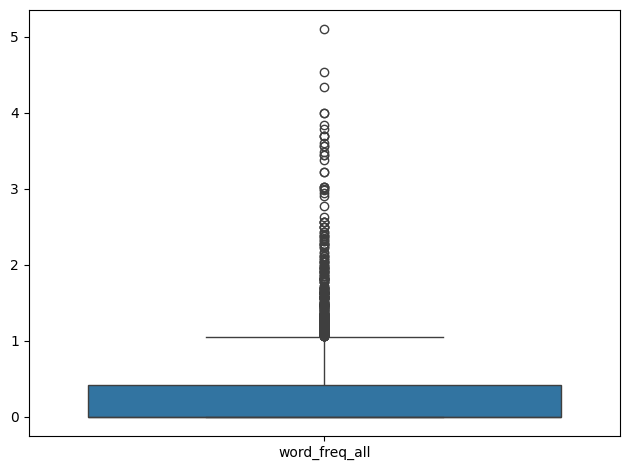

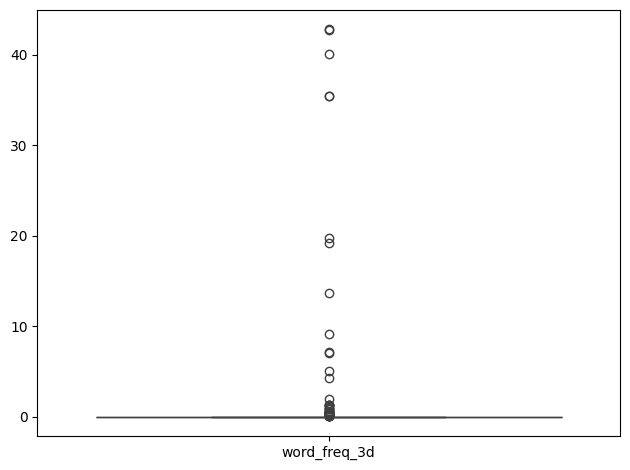

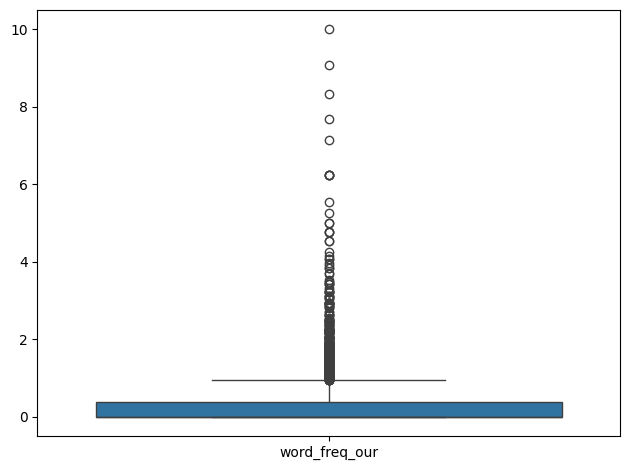

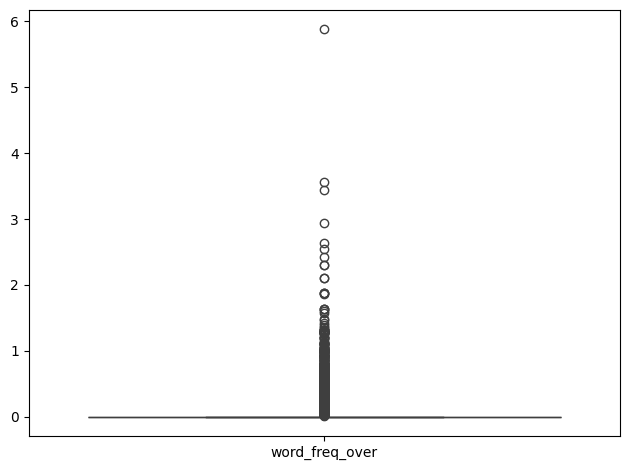

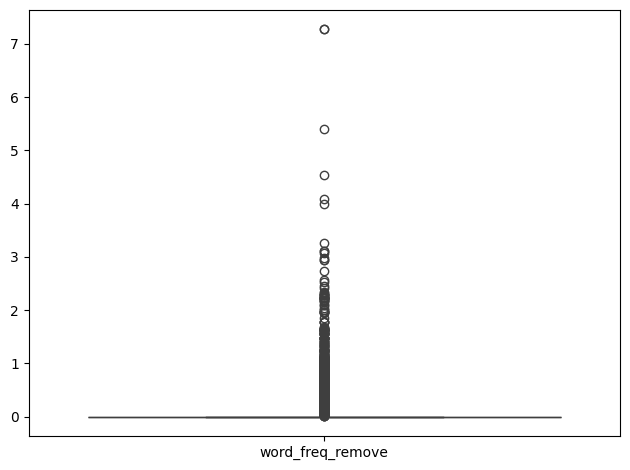

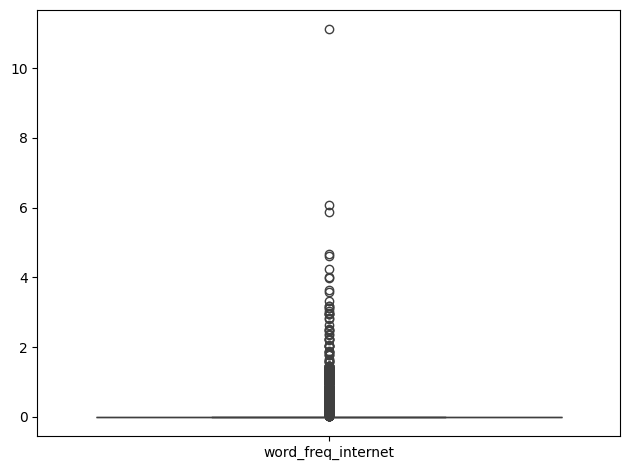

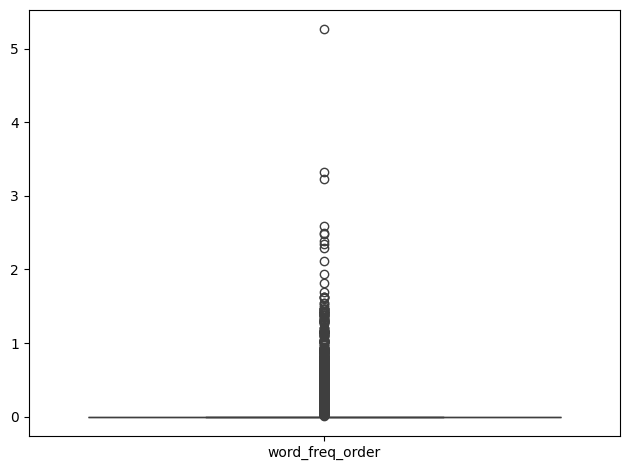

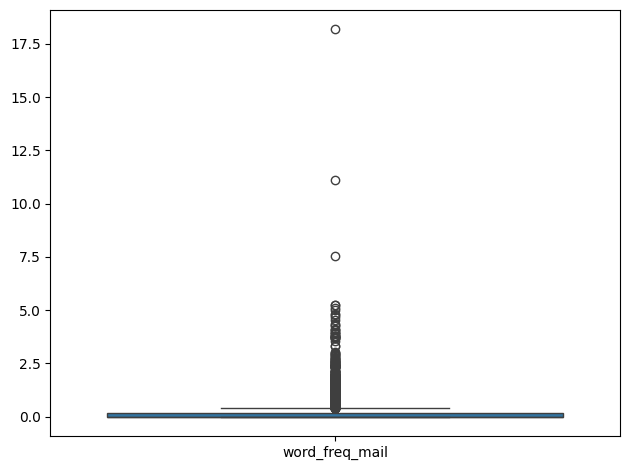

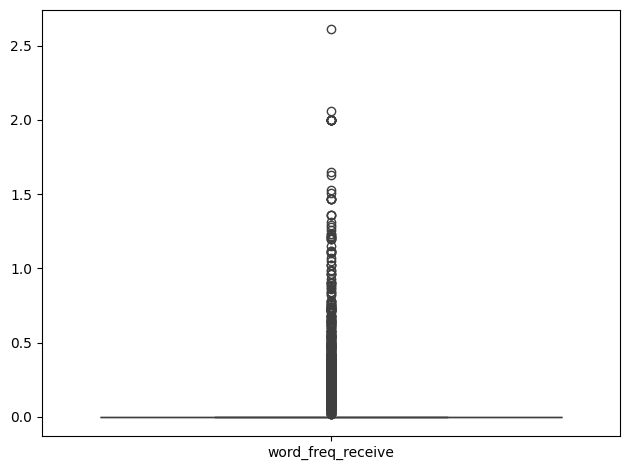

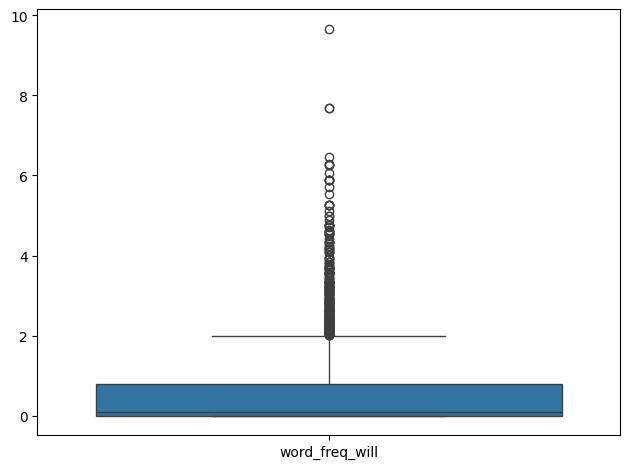

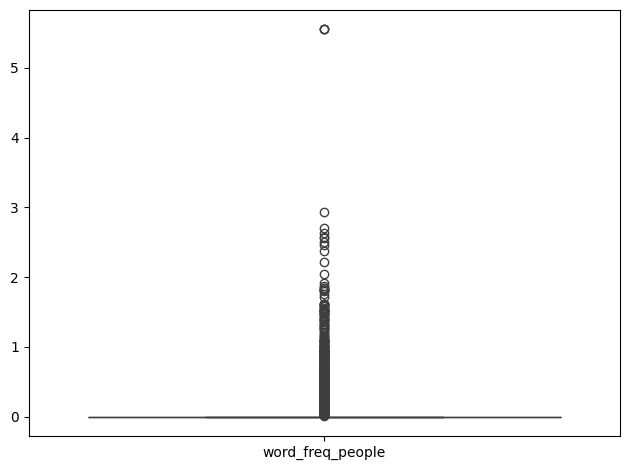

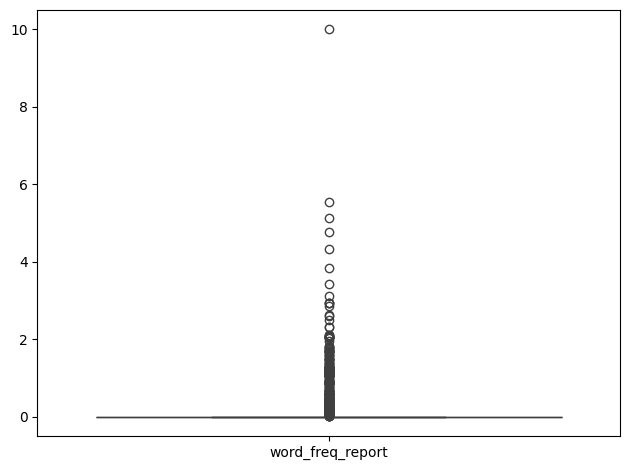

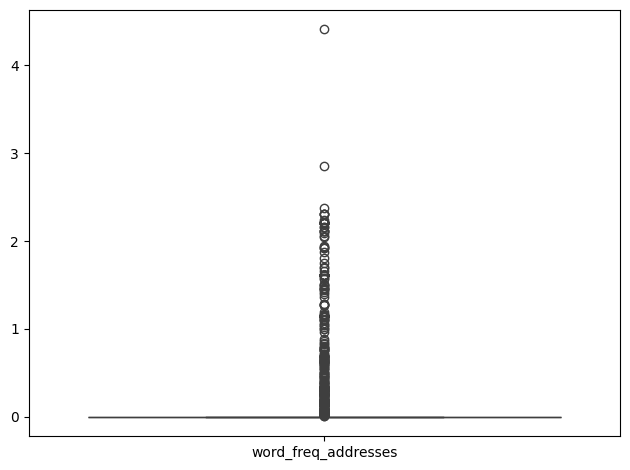

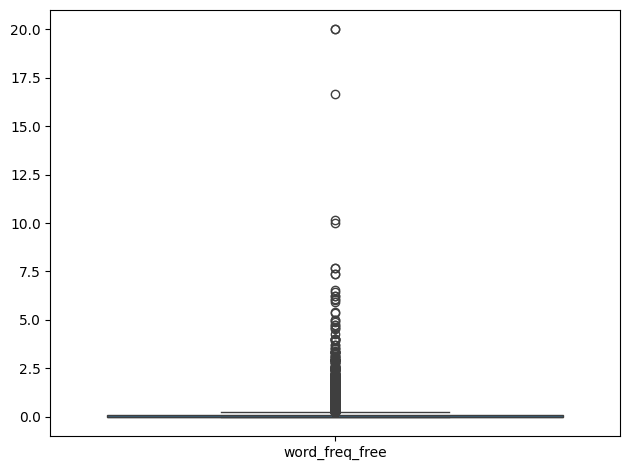

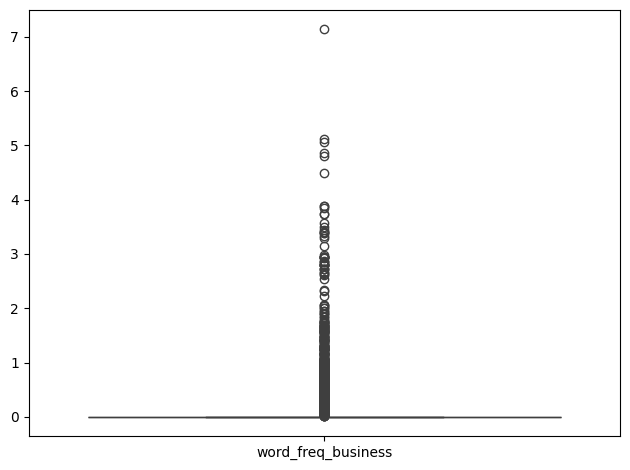

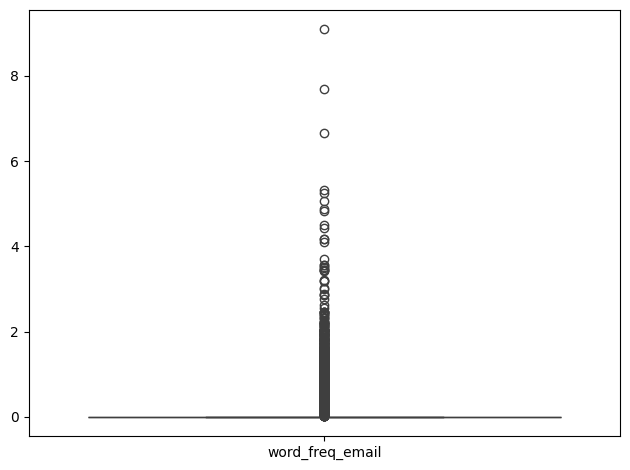

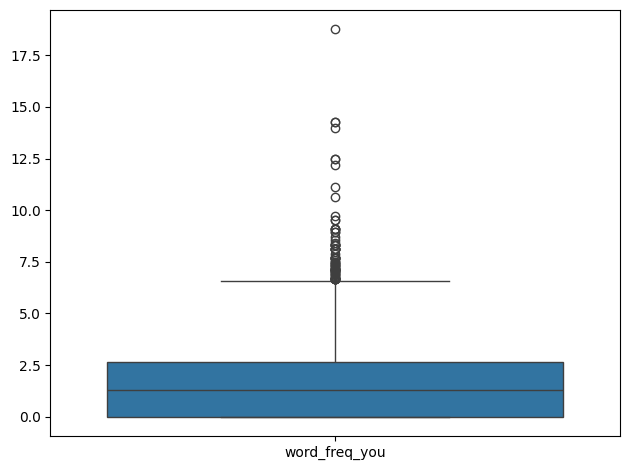

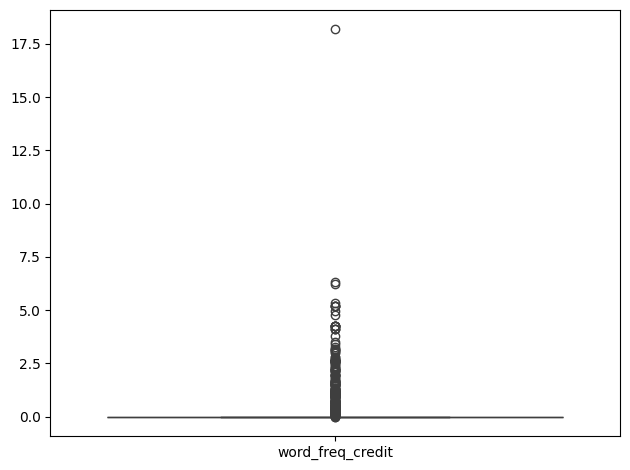

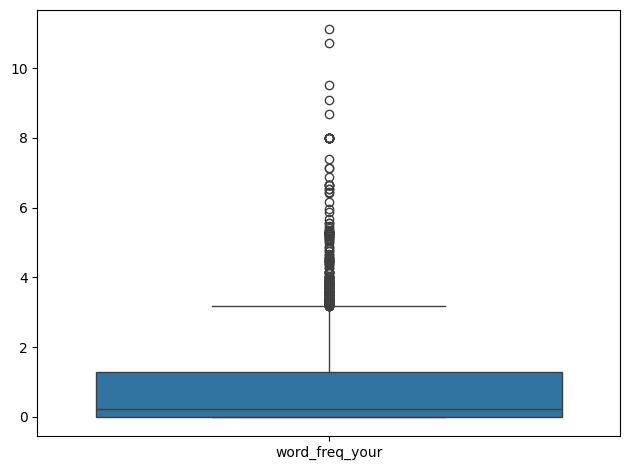

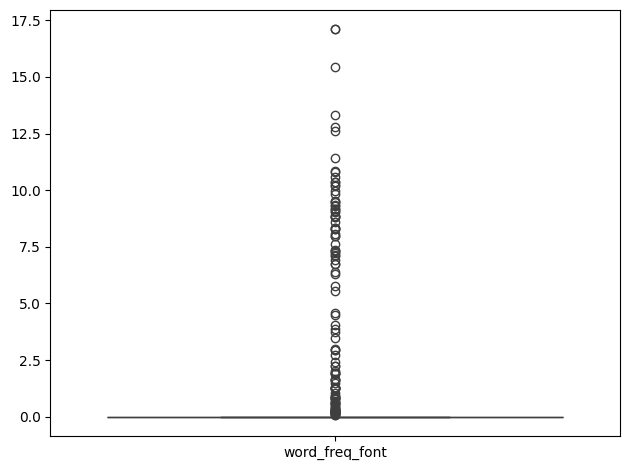

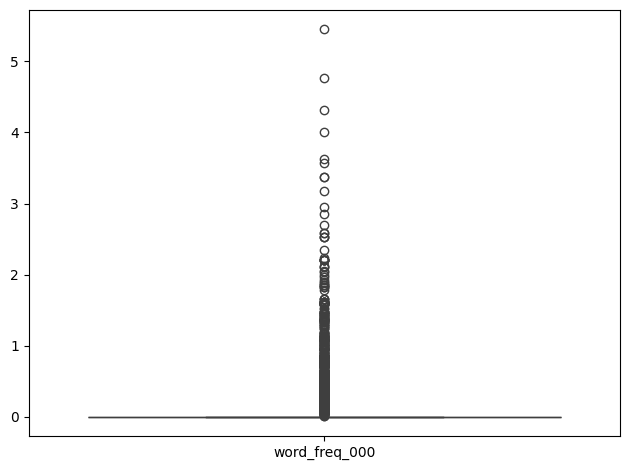

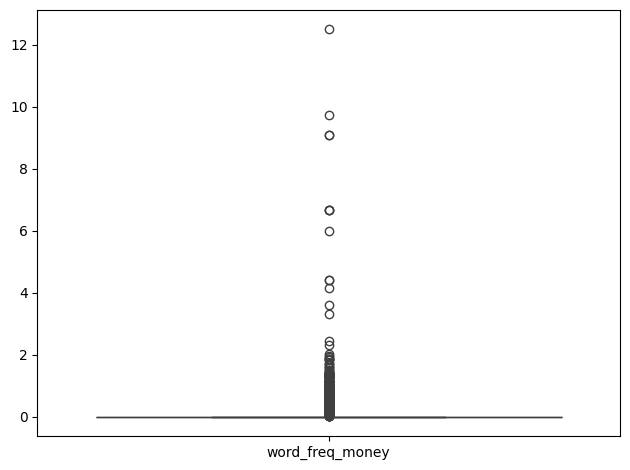

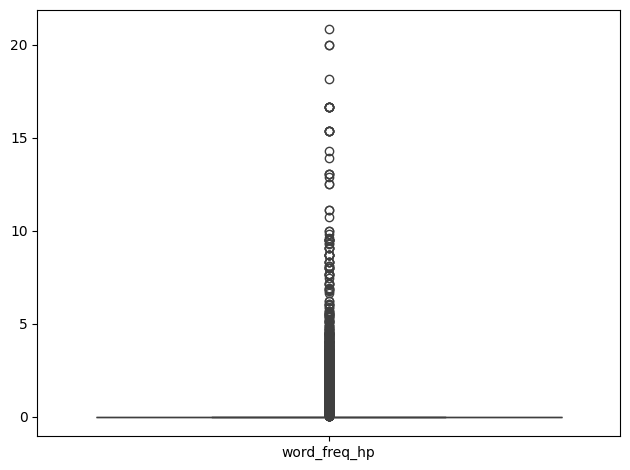

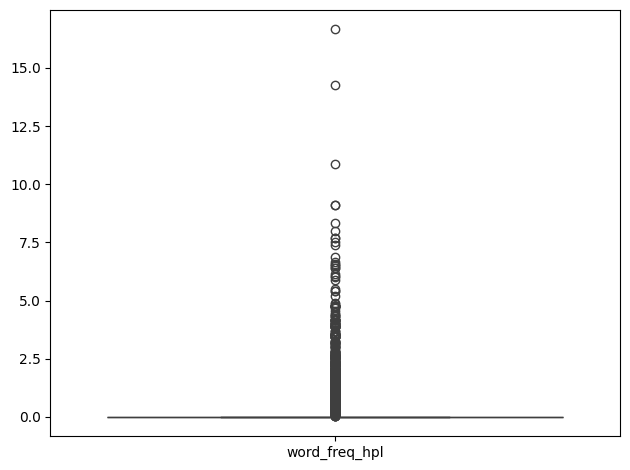

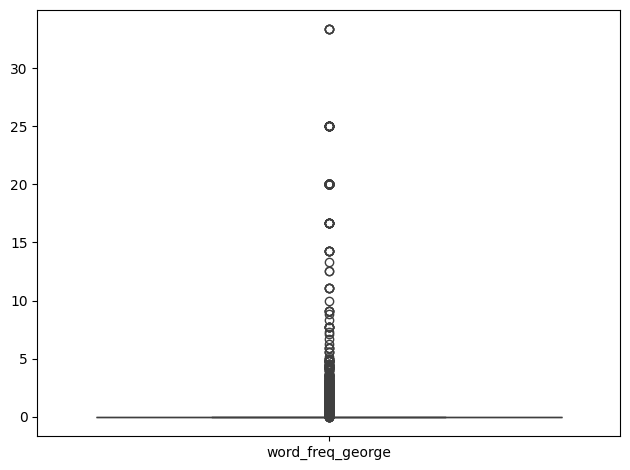

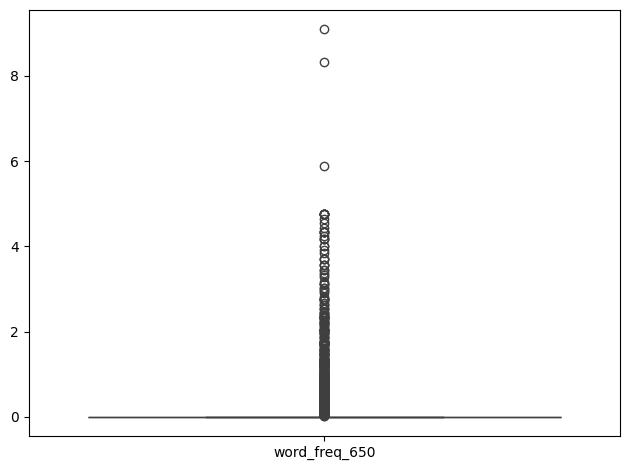

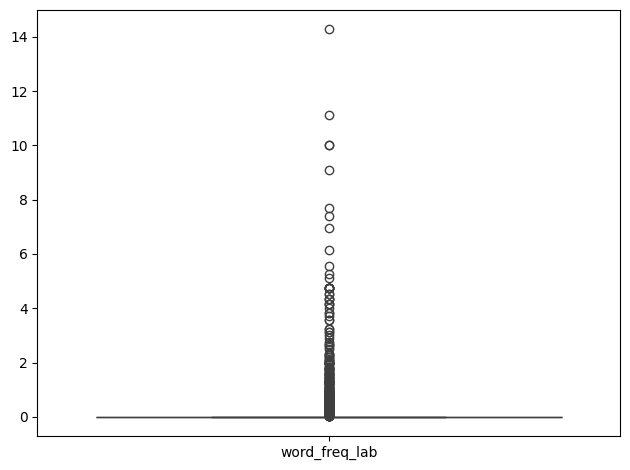

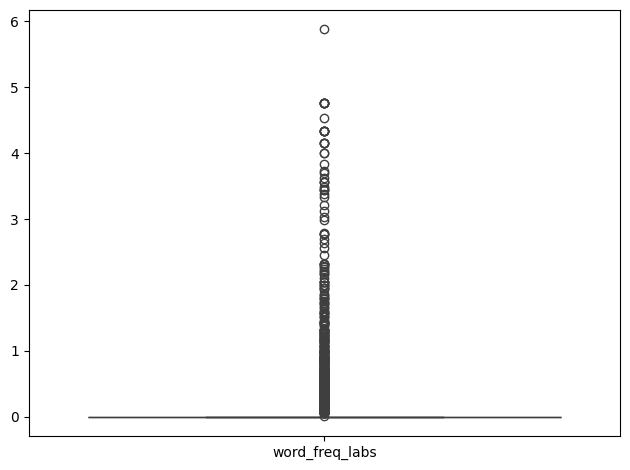

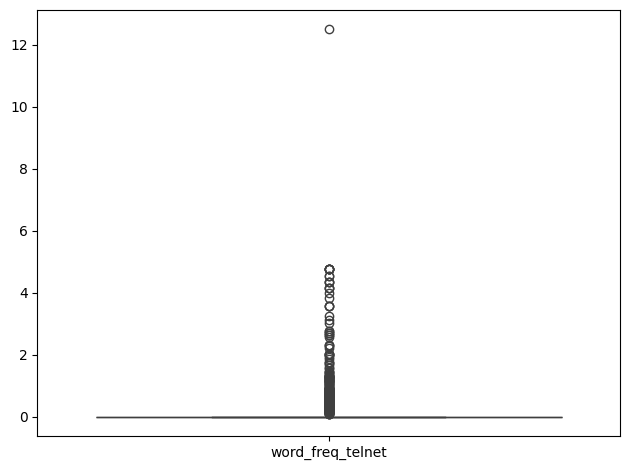

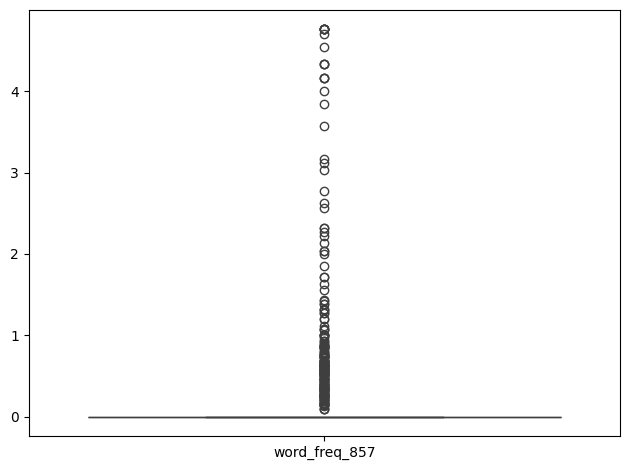

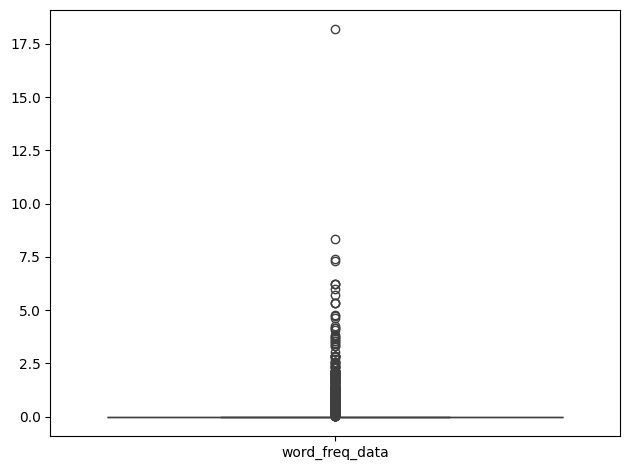

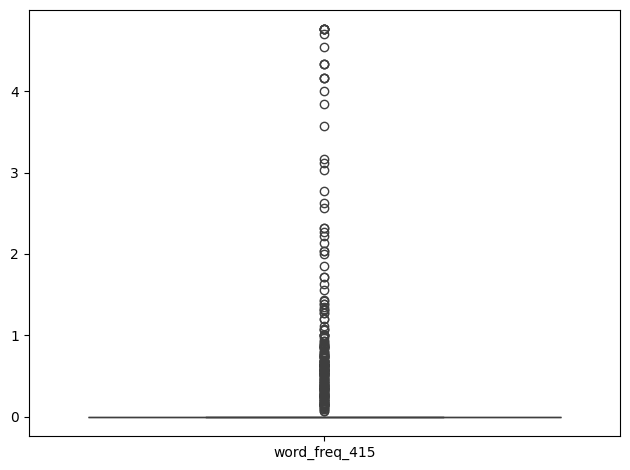

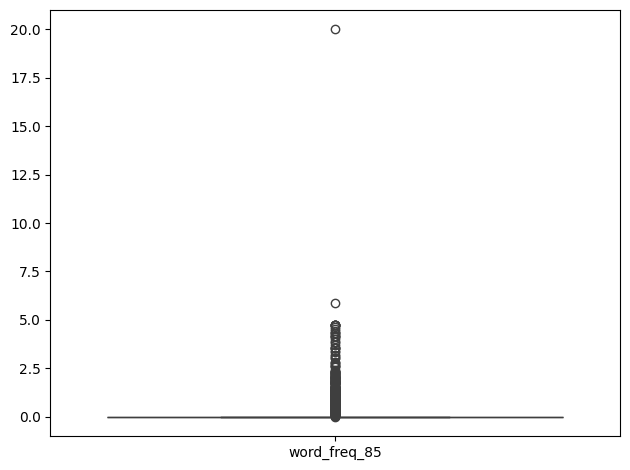

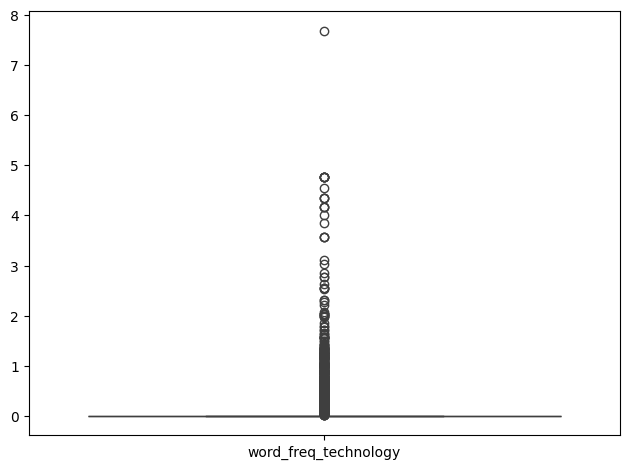

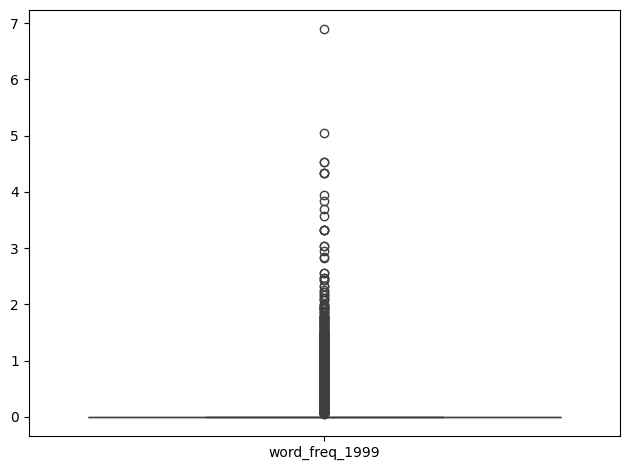

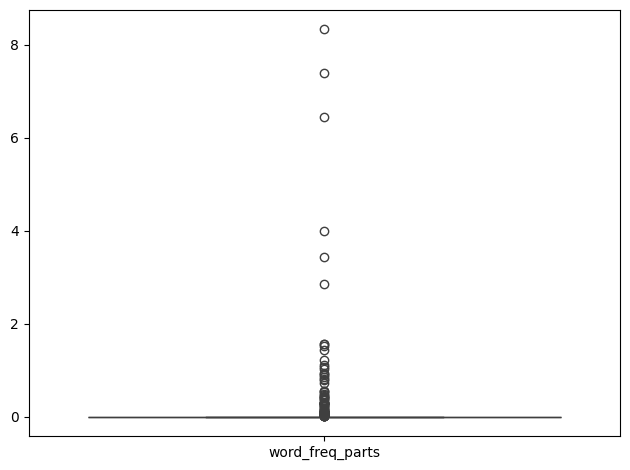

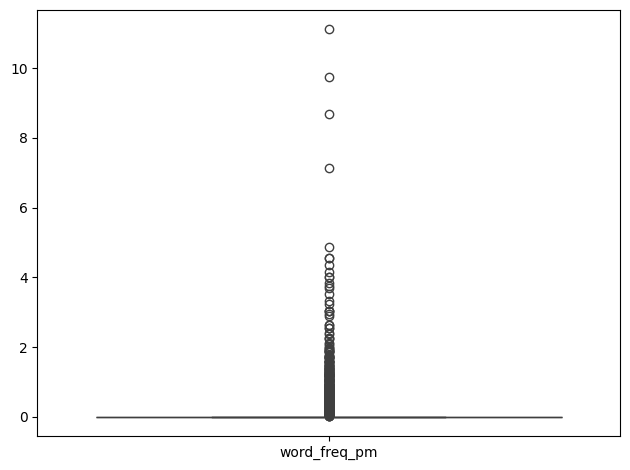

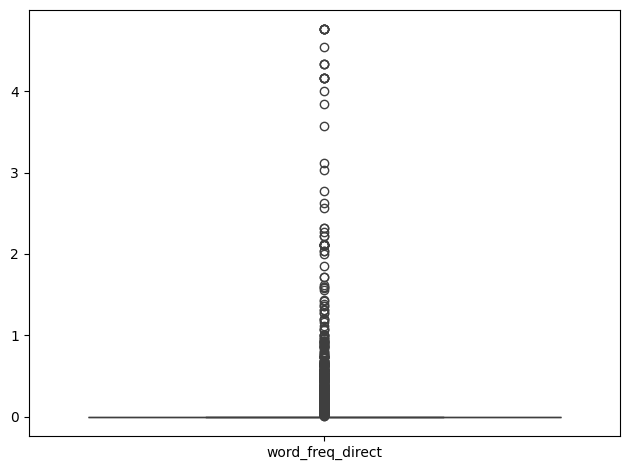

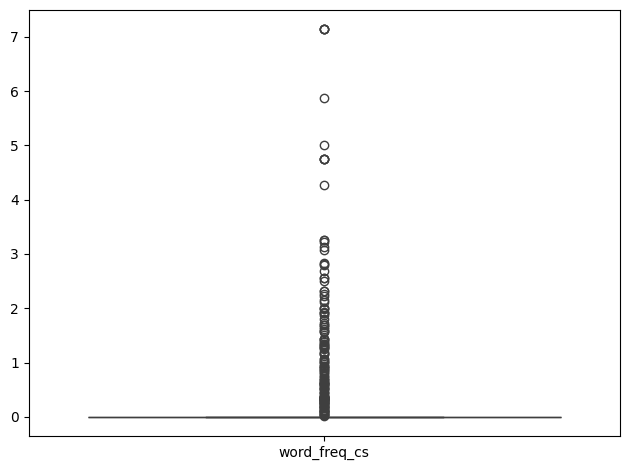

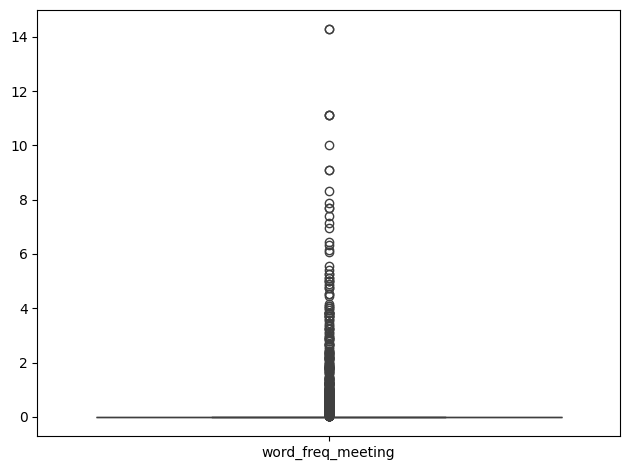

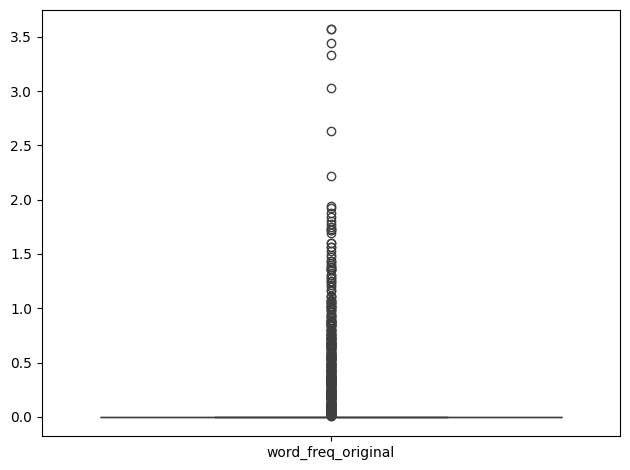

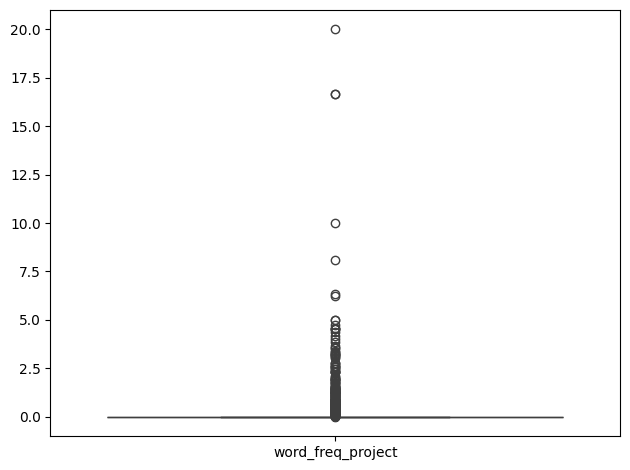

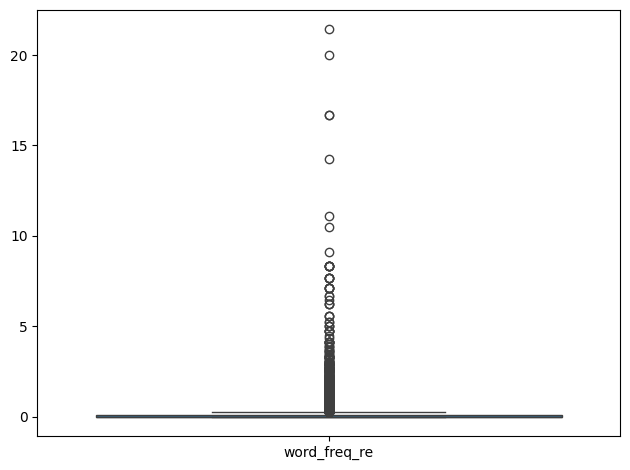

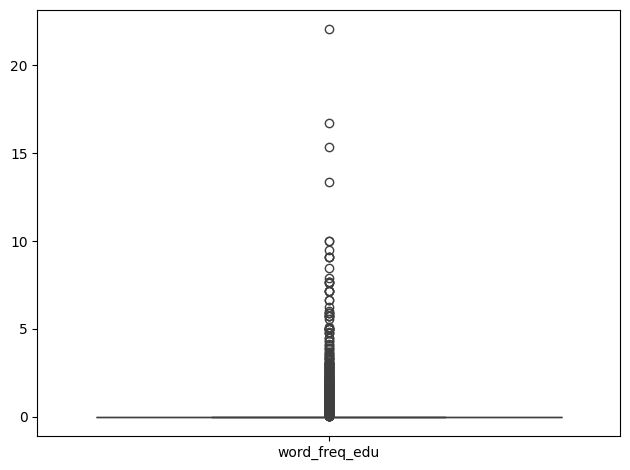

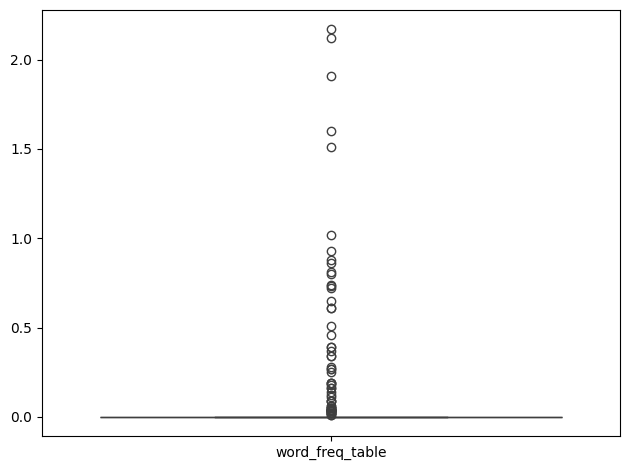

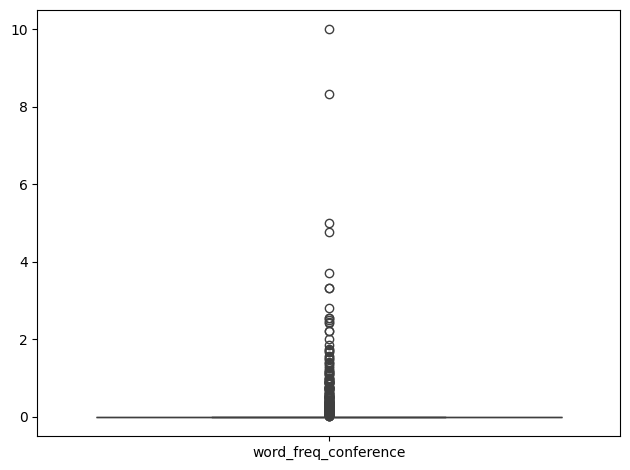

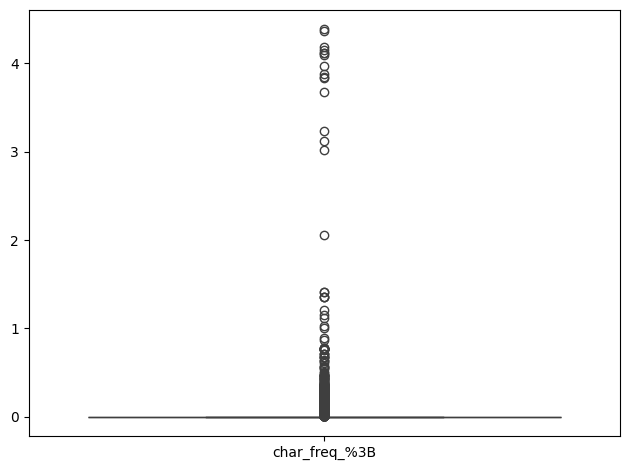

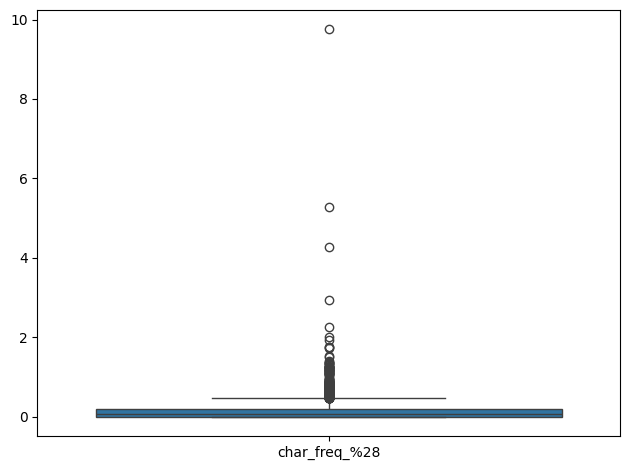

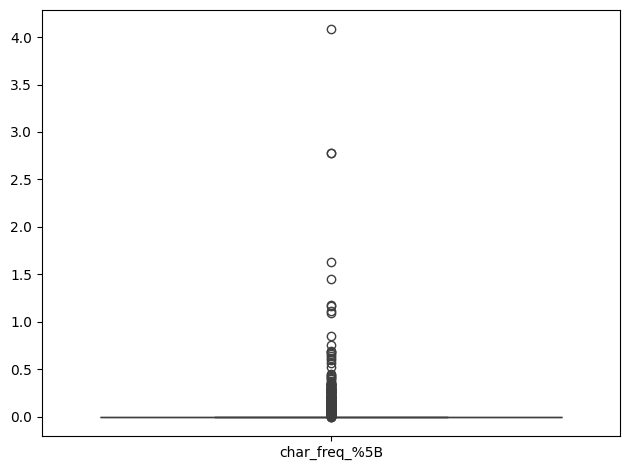

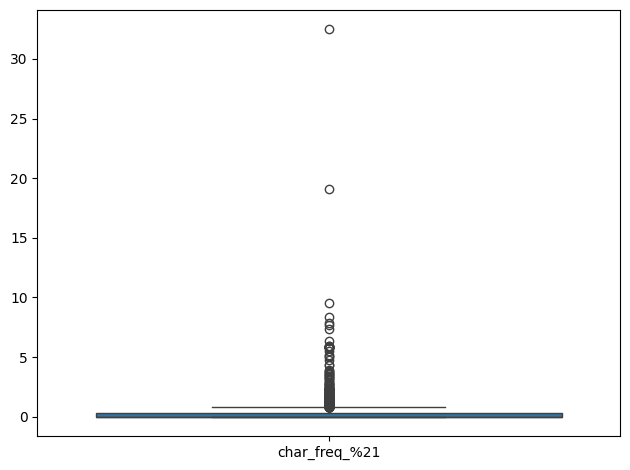

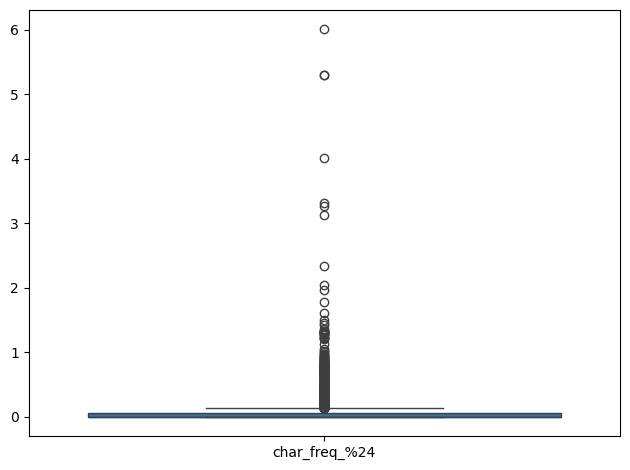

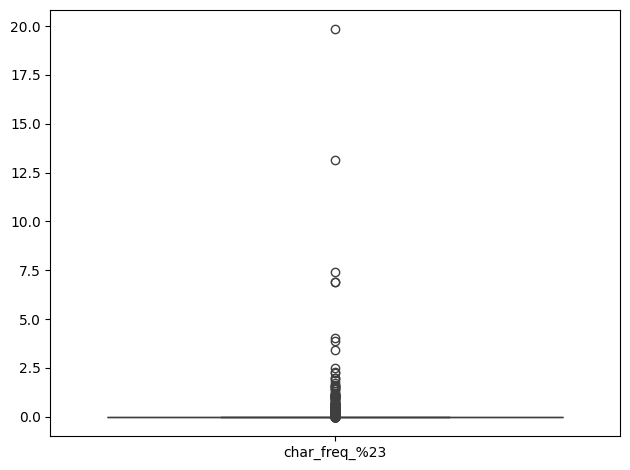

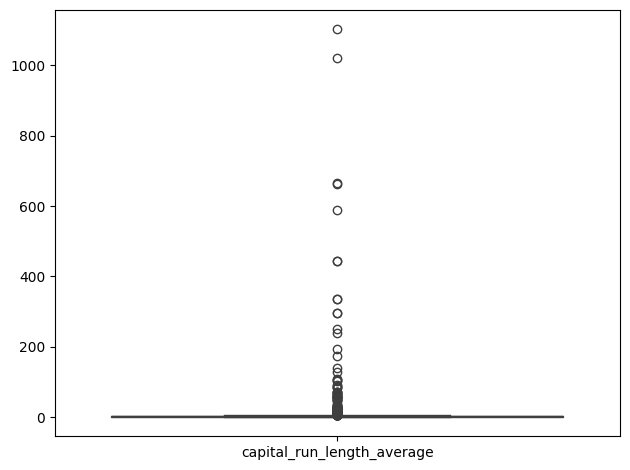

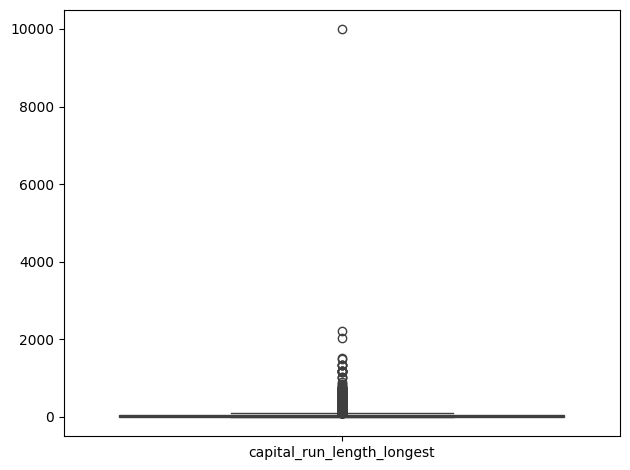

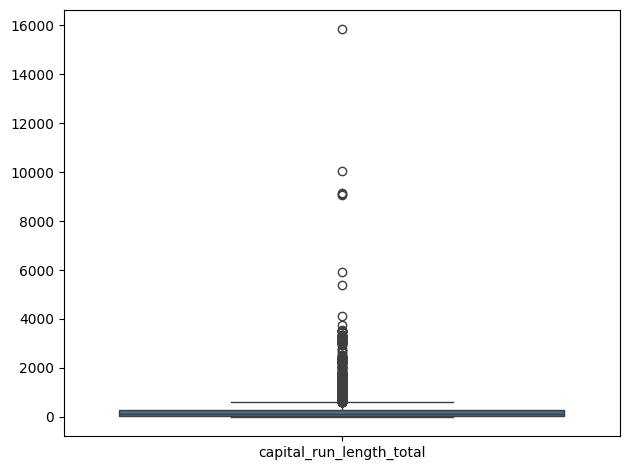

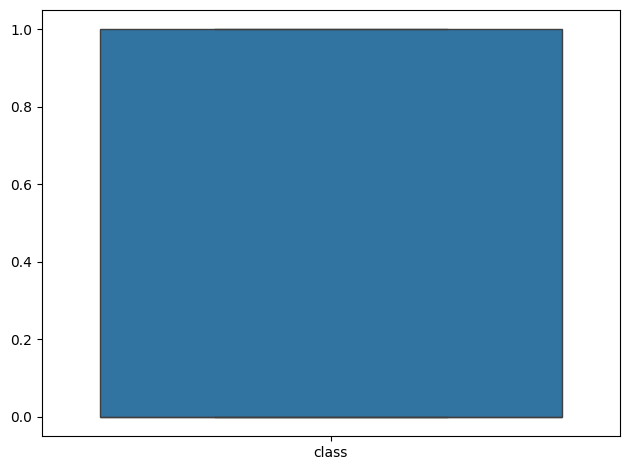

In [7]:
for col in data.columns:
  sns.boxplot(data[[col]])
  plt.tight_layout()
  plt.show()

In [8]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [9]:
'''for col in x.columns:
  Q1 = x[col].quantile(0.25)
  Q3 = x[col].quantile(0.75)
  IQR = Q3 - Q1
  low = Q1 - 1.5 * IQR
  high = Q3 + 1.5 * IQR

  x[col] = x[col].clip(low, high)'''

'for col in x.columns:\n  Q1 = x[col].quantile(0.25)\n  Q3 = x[col].quantile(0.75)\n  IQR = Q3 - Q1\n  low = Q1 - 1.5 * IQR\n  high = Q3 + 1.5 * IQR\n\n  x[col] = x[col].clip(low, high)'

In [10]:
'''for col in x.columns:
  sns.boxplot(col)
  plt.tight_layout()
  plt.show()'''

'for col in x.columns:\n  sns.boxplot(col)\n  plt.tight_layout()\n  plt.show()'

**(iii) Standarization / Normalization**

In [11]:
x.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [12]:
x_standard = x
standard = StandardScaler()

for col in x_standard:
  x_standard[col] = standard.fit_transform(x_standard[[col]])

x_standard.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.111546,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.111546,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222


In [13]:
x_norm = x
normalize = MinMaxScaler()

for col in x_norm:
  x_norm[col] = normalize.fit_transform(x_norm[[col]])

x_norm.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.000000,0.044818,0.125490,0.0,0.032,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.023955,0.000000,0.000000,0.002502,0.006007,0.017487
1,0.046256,0.019608,0.098039,0.0,0.014,0.047619,0.028886,0.006301,0.000000,0.051705,...,0.0,0.000000,0.013536,0.0,0.011454,0.029985,0.002421,0.003735,0.010012,0.064836
2,0.013216,0.000000,0.139216,0.0,0.123,0.032313,0.026135,0.010801,0.121673,0.013751,...,0.0,0.002281,0.014664,0.0,0.008498,0.030651,0.000504,0.008008,0.048458,0.142551
3,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.014048,0.0,0.004218,0.000000,0.000000,0.002303,0.003905,0.011995
4,0.000000,0.000000,0.000000,0.0,0.063,0.000000,0.042641,0.056706,0.058935,0.034653,...,0.0,0.000000,0.013843,0.0,0.004157,0.000000,0.000000,0.002303,0.003905,0.011995


#**Splitting**

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x_norm,y,test_size=0.5,random_state = 42)
x_val,x_test,y_val,y_test = train_test_split(x_test,y_test,test_size=0.2,random_state = 42)

In [15]:
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(2300, 57) (2300,)
(1840, 57) (1840,)
(461, 57) (461,)


#**Model Building**

#**SVC**


Accuracy Score of Testing  : 0.93058568329718
Precision Score of Testing : 0.9119496855345912
F1 Score of Testing        : 0.9006211180124224
Recall Score of Testing    : 0.8895705521472392

Confusion Matrix :- 
 [[1360   39]
 [  83  818]]


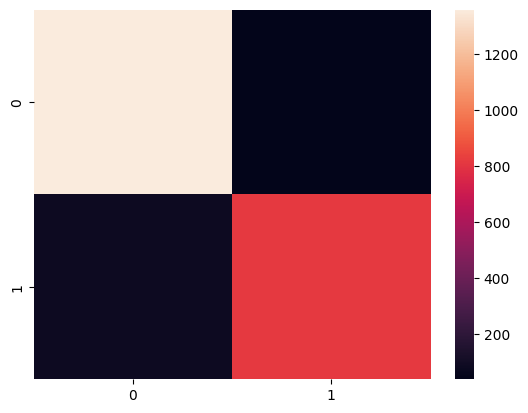

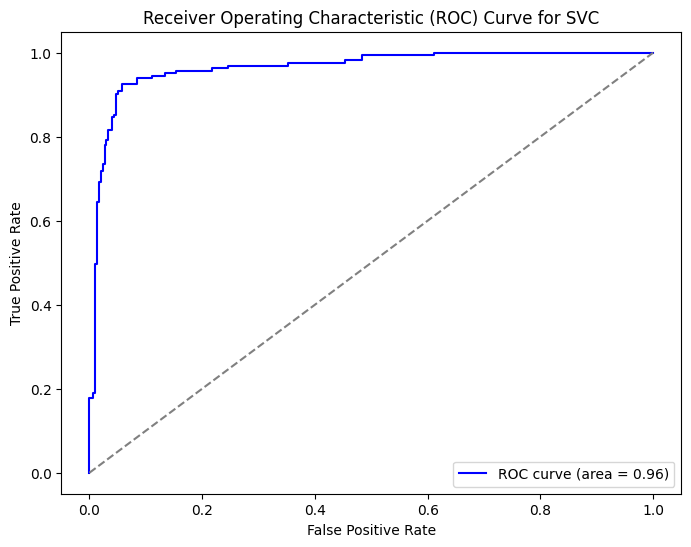

In [16]:
model = SVC(probability=True)
model.fit(x_train,y_train)
y_pre_train = model.predict(x_train)
con_train_model = confusion_matrix(y_train,y_pre_train)
#sns.heatmap(con_train_model)

accuracy_model_train = accuracy_score(y_train,y_pre_train)
precision_model_train = precision_score(y_train,y_pre_train)
f1_model_train = f1_score(y_train,y_pre_train)
recall_model_train = recall_score(y_train,y_pre_train)

'''print("Accuracy Score of Training  :",accuracy_model_train)
print("Precision Score of Training :",precision_model_train)
print("F1 Score of Training        :",f1_model_train)
print("Recall Score of Training    :",recall_model_train)
print("\nConfusion Matrix :- \n",con_train_model)'''

y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]

fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)

roc_auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for SVC')
plt.legend(loc='lower right')
plt.show()

**Parameters of the Model**

In [17]:
model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

#**Grid Search CV**

In [18]:
params = [
    # For poly kernel → gamma & degree both used
    {
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5],
        'gamma': ['scale', 'auto', 0.1, 1.0],
        'C': [0.1, 1, 10]
    },
    # For rbf kernel → gamma used, degree ignored
    {
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
        'C': [0.1, 1, 10]
    },
    # For sigmoid kernel → gamma used, degree ignored
    {
        'kernel': ['sigmoid'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
        'C': [0.1, 1, 10]
    },
    # For linear kernel → gamma & degree ignored
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    }]

for i in params:
  grid = GridSearchCV(SVC(),param_grid = i, cv = 5)
  grid.fit(x_val,y_val)
  print(grid.best_params_)
  print(grid.best_score_)

{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
0.8956521739130435
{'C': 10, 'gamma': 1.0, 'kernel': 'rbf'}
0.9228260869565219
{'C': 10, 'gamma': 1.0, 'kernel': 'sigmoid'}
0.8896739130434783
{'C': 10, 'kernel': 'linear'}
0.9097826086956522


#**Randomized Search CV**

In [19]:
params = [
    # For poly kernel → gamma & degree both used
    {
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5],
        'gamma': ['scale', 'auto', 0.1, 1.0],
        'C': [0.1, 1, 10]
    },
    # For rbf kernel → gamma used, degree ignored
    {
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
        'C': [0.1, 1, 10]
    },
    # For sigmoid kernel → gamma used, degree ignored
    {
        'kernel': ['sigmoid'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
        'C': [0.1, 1, 10]
    },
    # For linear kernel → gamma & degree ignored
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    }]

for i in params:
  random = RandomizedSearchCV(SVC(),param_distributions = i, cv = 5)
  random.fit(x_val,y_val)
  print(random.best_params_)
  print(random.best_score_)

{'kernel': 'poly', 'gamma': 1.0, 'degree': 2, 'C': 1}
0.7527173913043479
{'kernel': 'rbf', 'gamma': 1.0, 'C': 10}
0.9228260869565219
{'kernel': 'sigmoid', 'gamma': 1.0, 'C': 1}
0.8793478260869565


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'kernel': 'linear', 'C': 10}
0.9097826086956522


#**Testing**

**(i) Poly Kernel**


Accuracy Score of Testing  : 0.9045553145336226
Precision Score of Testing : 0.8993288590604027
F1 Score of Testing        : 0.8589743589743589
Recall Score of Testing    : 0.8220858895705522

Confusion Matrix :- 
 [[1360   39]
 [  83  818]]


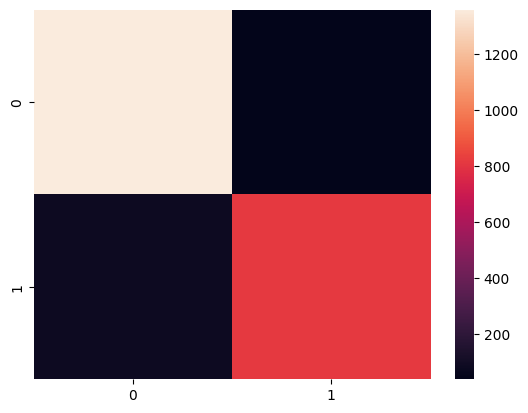

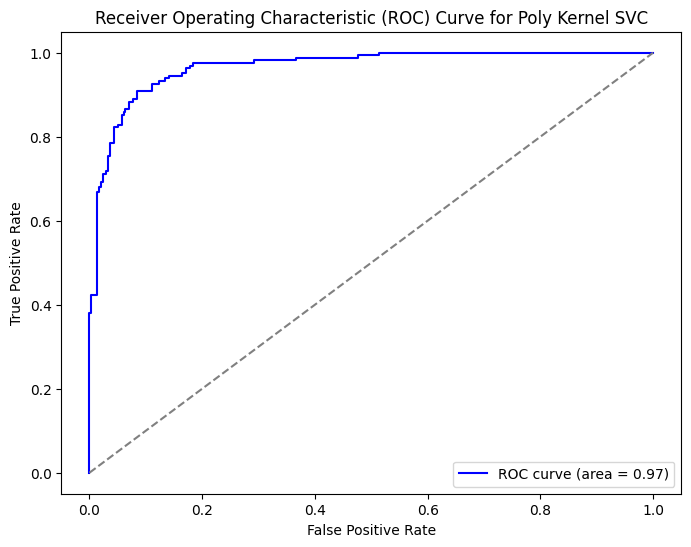

In [20]:
model = SVC(C = 10, degree = 2, gamma = 'scale', kernel = 'poly',probability = True)

model.fit(x_train,y_train)
y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)
roc_auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Poly Kernel SVC')
plt.legend(loc='lower right')
plt.show()

**(ii) RBF Kernel**


Accuracy Score of Testing  : 0.9219088937093276
Precision Score of Testing : 0.8895705521472392
F1 Score of Testing        : 0.8895705521472392
Recall Score of Testing    : 0.8895705521472392

Confusion Matrix :- 
 [[1360   39]
 [  83  818]]


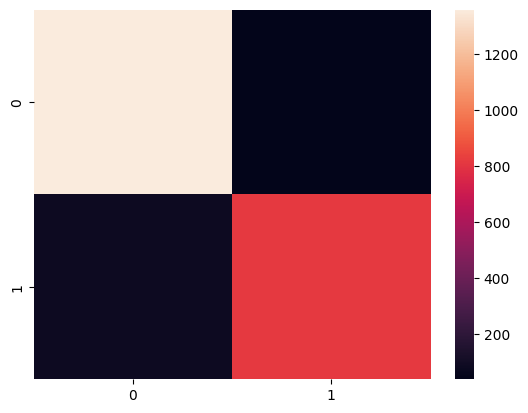

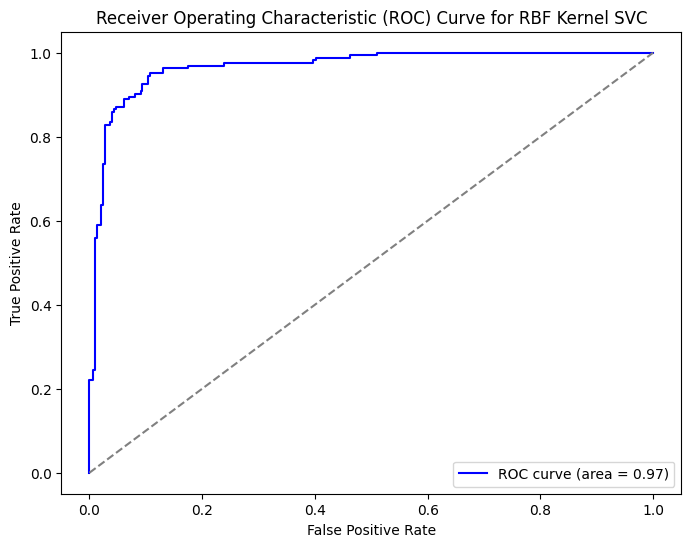

In [21]:
model = SVC(kernel= 'rbf', gamma= 'scale', C= 10, probability = True)

model.fit(x_train,y_train)
y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)
roc_auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for RBF Kernel SVC')
plt.legend(loc='lower right')
plt.show()

**Sigmoid Kernel**


Accuracy Score of Testing  : 0.8828633405639913
Precision Score of Testing : 0.8471337579617835
F1 Score of Testing        : 0.83125
Recall Score of Testing    : 0.8159509202453987

Confusion Matrix :- 
 [[1360   39]
 [  83  818]]


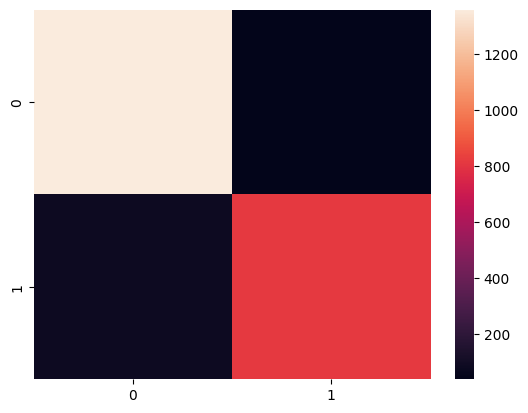

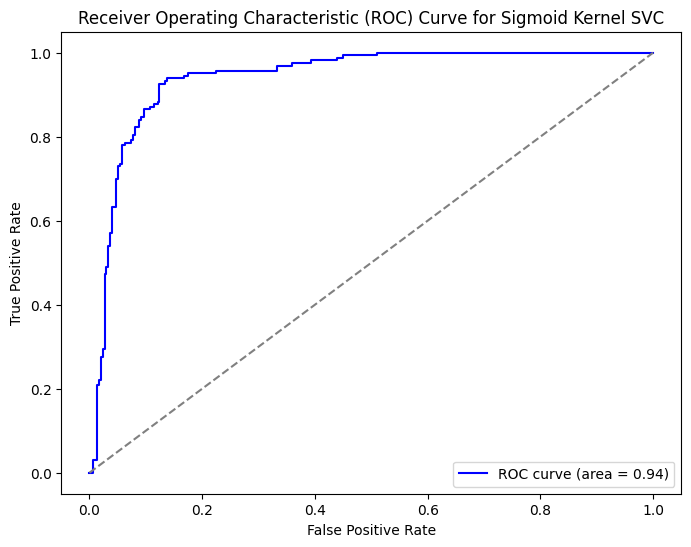

In [22]:
model = SVC(kernel= 'sigmoid', gamma= 1.0, C= 10,probability = True)

model.fit(x_train,y_train)
y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)
roc_auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Sigmoid Kernel SVC')
plt.legend(loc='lower right')
plt.show()

**Linear Kernel**


Accuracy Score of Testing  : 0.9154013015184381
Precision Score of Testing : 0.8780487804878049
F1 Score of Testing        : 0.8807339449541285
Recall Score of Testing    : 0.8834355828220859

Confusion Matrix :- 
 [[1360   39]
 [  83  818]]


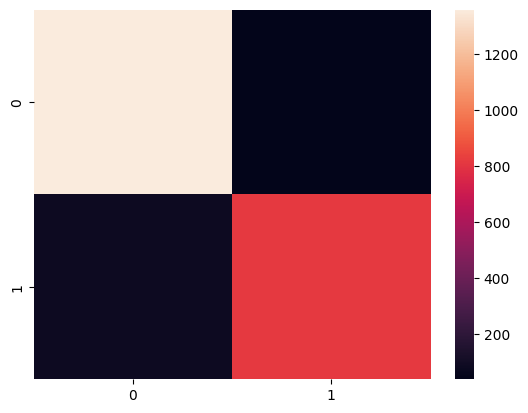

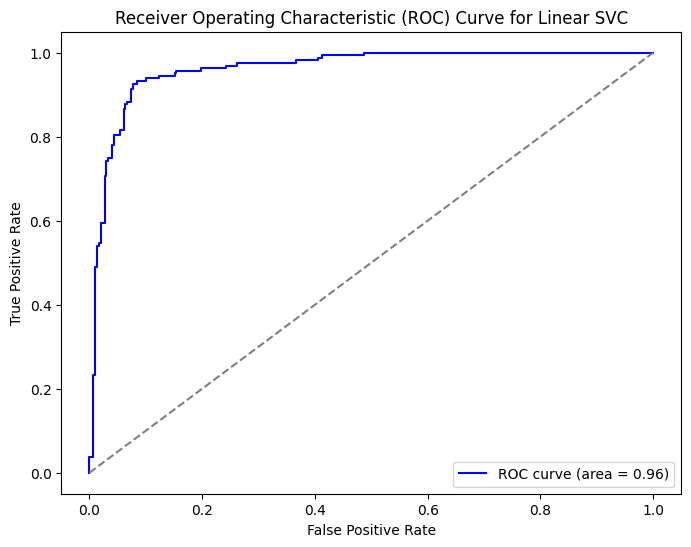

In [23]:
model = SVC(C= 10, kernel= 'linear',probability = True)

model.fit(x_train,y_train)
y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model)

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)
roc_auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Linear SVC')
plt.legend(loc='lower right')
plt.show()

#**Cross validation**

**(i) Poly kernel**


----- Fold ------

Accuracy Score of Testing  : 0.9207383279044516
Precision Score of Testing : 0.9567723342939481
F1 Score of Testing        : 0.9009497964721845
Recall Score of Testing    : 0.8512820512820513

Confusion Matrix :- 
 [[2214   43]
 [ 180 1243]]


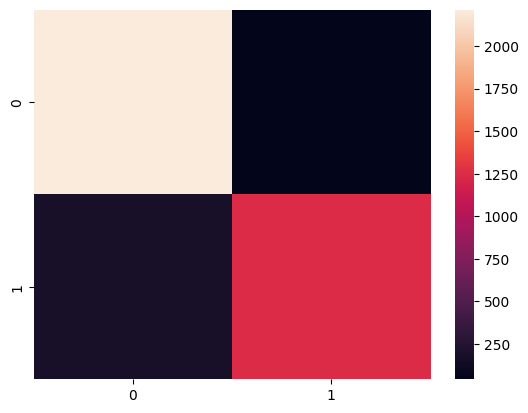

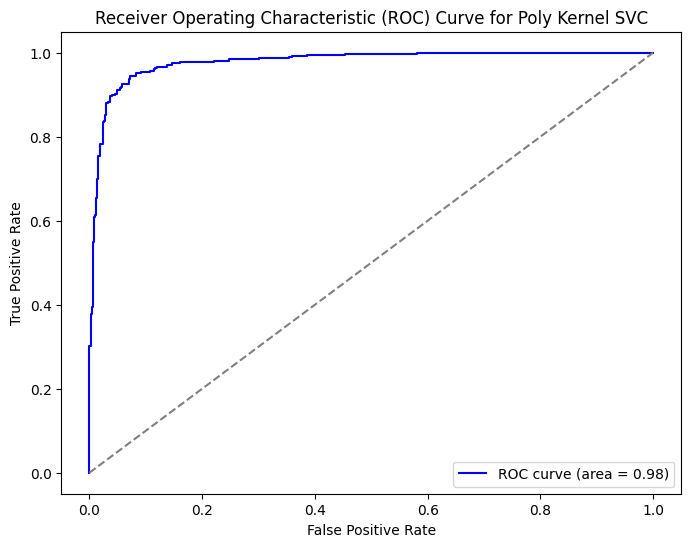


----- Fold ------

Accuracy Score of Testing  : 0.9326086956521739
Precision Score of Testing : 0.9411764705882353
F1 Score of Testing        : 0.9116809116809117
Recall Score of Testing    : 0.8839779005524862

Confusion Matrix :- 
 [[2190   40]
 [ 176 1275]]


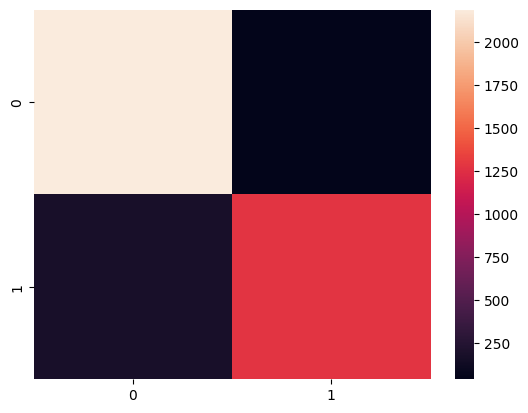

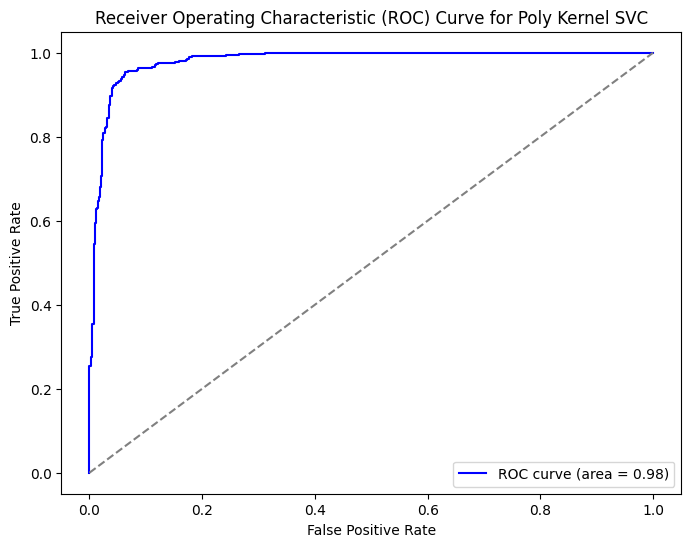


----- Fold ------

Accuracy Score of Testing  : 0.9184782608695652
Precision Score of Testing : 0.926605504587156
F1 Score of Testing        : 0.8898678414096917
Recall Score of Testing    : 0.8559322033898306

Confusion Matrix :- 
 [[2180   42]
 [ 162 1297]]


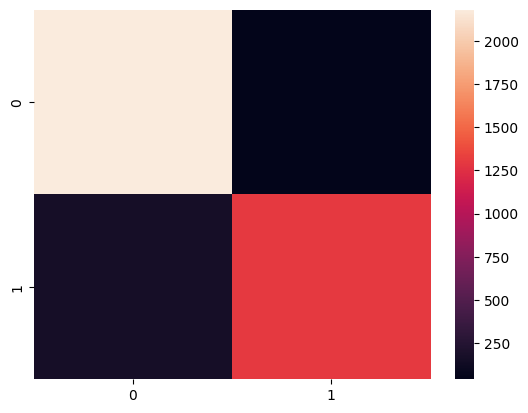

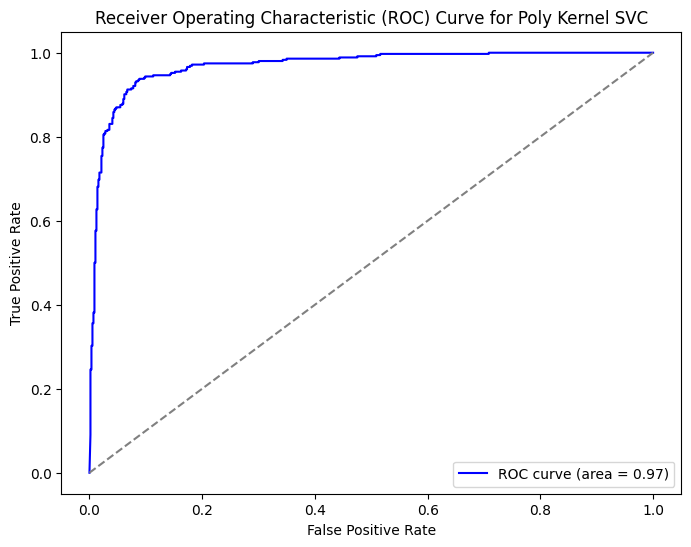


----- Fold ------

Accuracy Score of Testing  : 0.9228260869565217
Precision Score of Testing : 0.9314641744548287
F1 Score of Testing        : 0.8938714499252616
Recall Score of Testing    : 0.8591954022988506

Confusion Matrix :- 
 [[2181   35]
 [ 170 1295]]


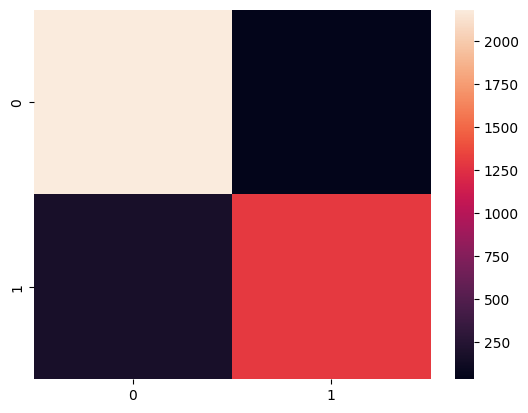

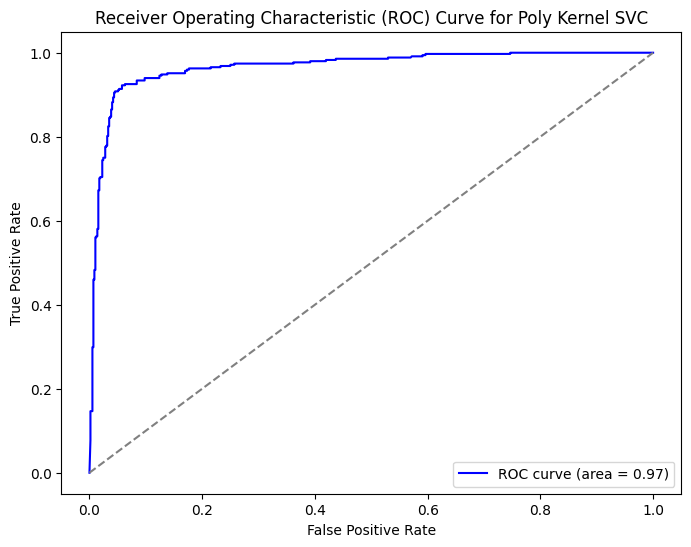


----- Fold ------

Accuracy Score of Testing  : 0.9141304347826087
Precision Score of Testing : 0.9294478527607362
F1 Score of Testing        : 0.8846715328467153
Recall Score of Testing    : 0.8440111420612814

Confusion Matrix :- 
 [[2189   38]
 [ 169 1285]]


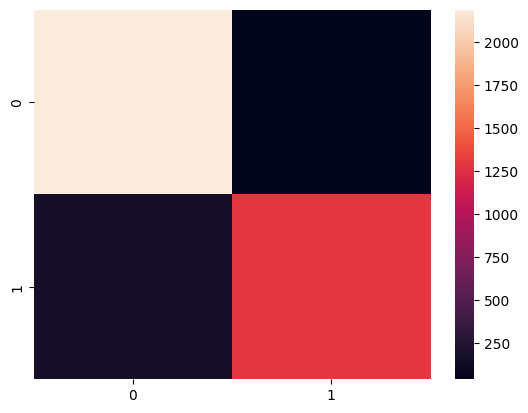

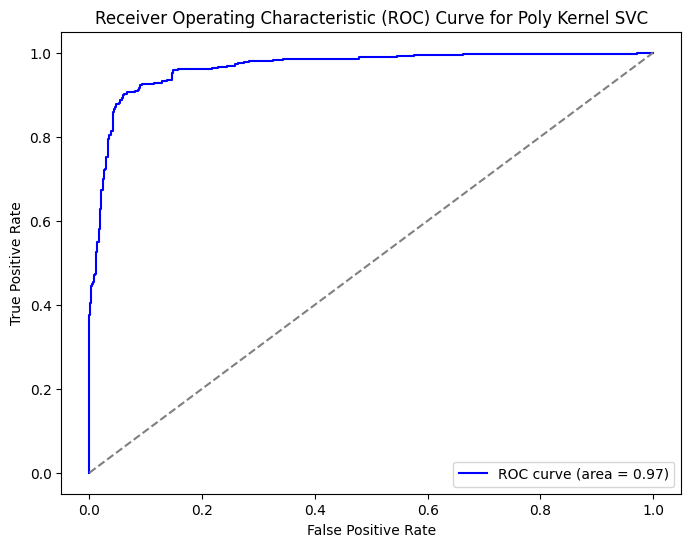

In [24]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = SVC(C = 10, degree = 2, gamma = 'scale', kernel = 'poly',probability = True)
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)'''

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]
  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)
  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for Poly Kernel SVC')
  plt.legend(loc='lower right')
  plt.show()

In [25]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for Poly Kernel SVC :-\n")
df

K Fold for Poly Kernel SVC :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.920738,0.956772,0.900950,0.851282,0.978140
1,2,0.932609,0.941176,0.911681,0.883978,0.980891
2,3,0.918478,0.926606,0.889868,0.855932,0.969186
3,4,0.922826,0.931464,0.893871,0.859195,0.966155
4,5,0.914130,0.929448,0.884672,0.844011,0.965377
5,Mean,0.921756,0.937093,0.896208,0.858880,0.971950


**(ii) RBF Kernel**


----- Fold ------

Accuracy Score of Testing  : 0.9348534201954397
Precision Score of Testing : 0.9508196721311475
F1 Score of Testing        : 0.9206349206349206
Recall Score of Testing    : 0.8923076923076924

Confusion Matrix :- 
 [[2216   41]
 [  86 1337]]


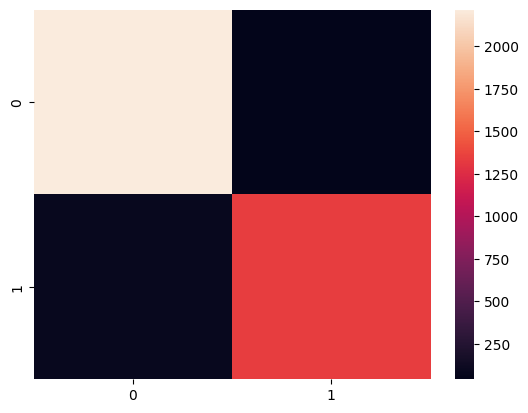

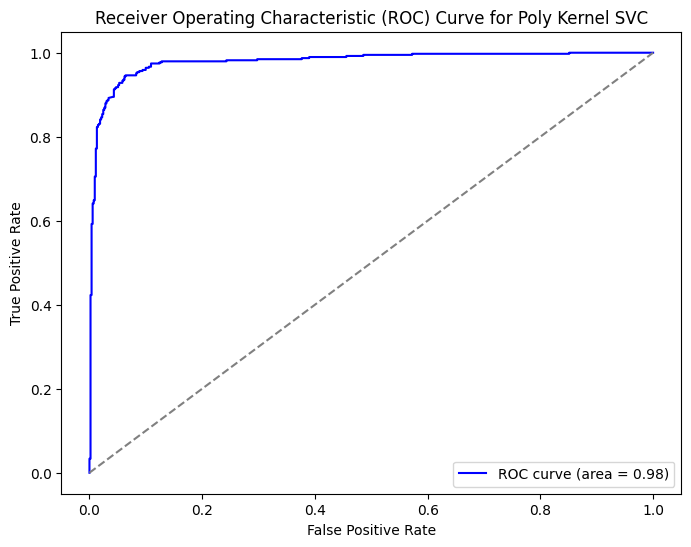


----- Fold ------

Accuracy Score of Testing  : 0.9347826086956522
Precision Score of Testing : 0.9194444444444444
F1 Score of Testing        : 0.9168975069252078
Recall Score of Testing    : 0.914364640883978

Confusion Matrix :- 
 [[2190   40]
 [  88 1363]]


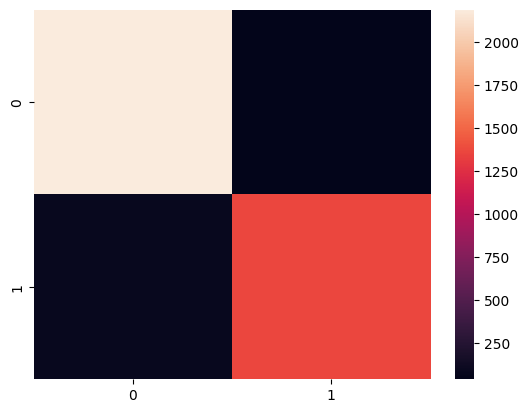

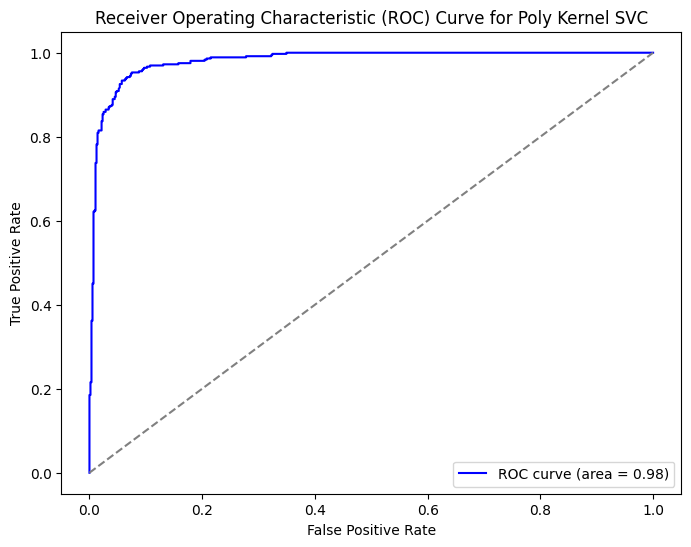


----- Fold ------

Accuracy Score of Testing  : 0.933695652173913
Precision Score of Testing : 0.9296187683284457
F1 Score of Testing        : 0.9122302158273381
Recall Score of Testing    : 0.8954802259887006

Confusion Matrix :- 
 [[2188   34]
 [  85 1374]]


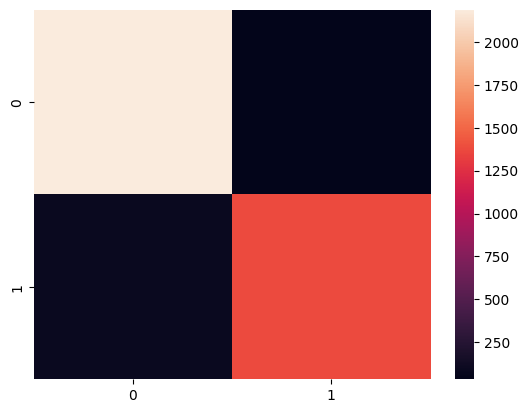

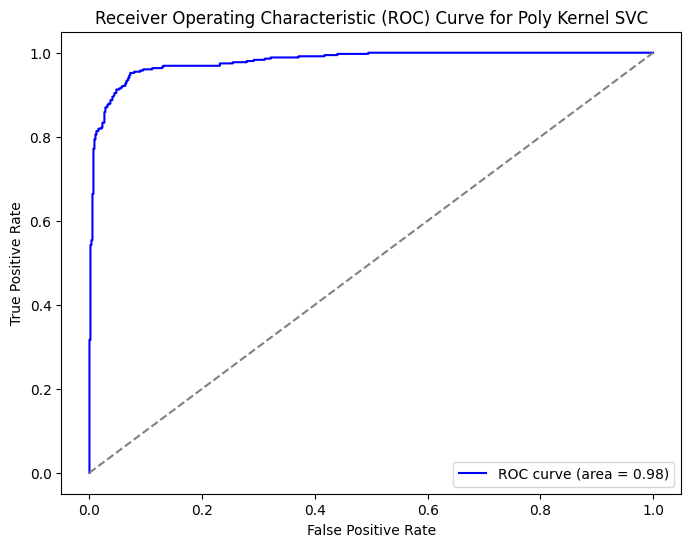


----- Fold ------

Accuracy Score of Testing  : 0.933695652173913
Precision Score of Testing : 0.9258160237388724
F1 Score of Testing        : 0.910948905109489
Recall Score of Testing    : 0.896551724137931

Confusion Matrix :- 
 [[2179   37]
 [  88 1377]]


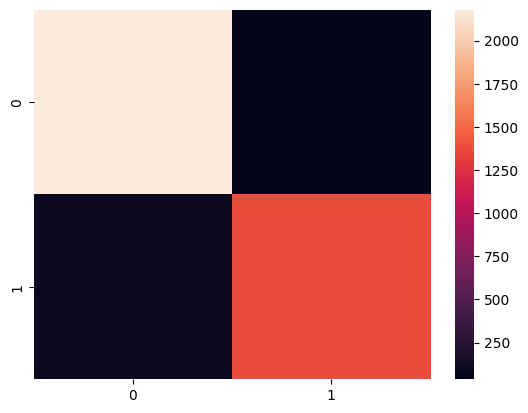

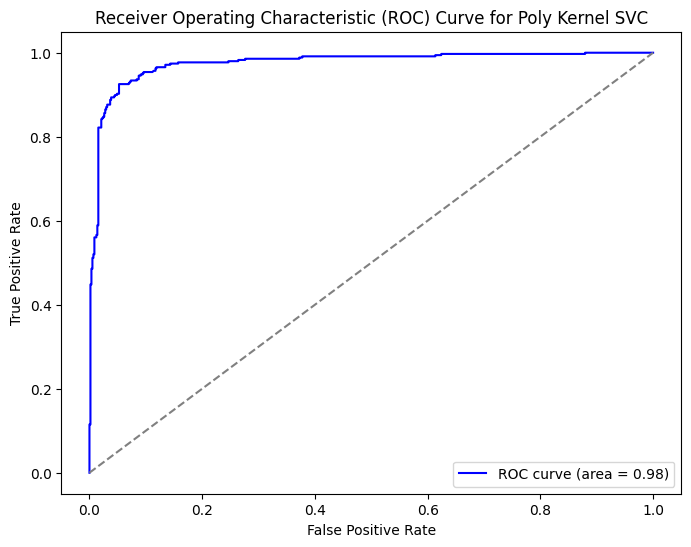


----- Fold ------

Accuracy Score of Testing  : 0.9347826086956522
Precision Score of Testing : 0.9358600583090378
F1 Score of Testing        : 0.9145299145299145
Recall Score of Testing    : 0.8941504178272981

Confusion Matrix :- 
 [[2192   35]
 [  97 1357]]


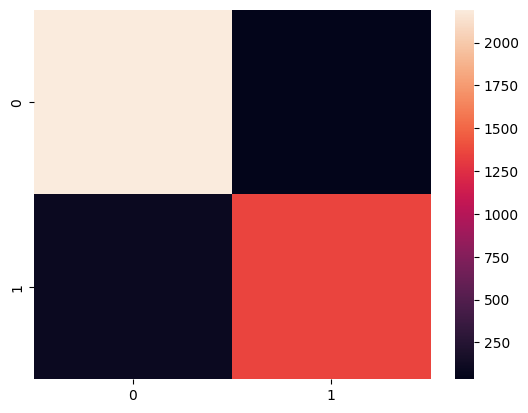

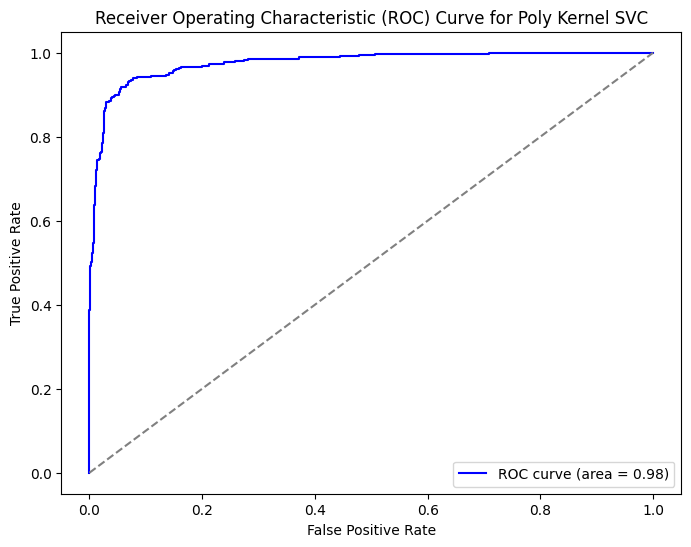

In [26]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = SVC(kernel= 'rbf', gamma= 'scale', C= 10, probability = True)
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)'''

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]
  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)
  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for Poly Kernel SVC')
  plt.legend(loc='lower right')
  plt.show()

In [27]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for RBF Kernel SVC :-\n")
df

K Fold for RBF Kernel SVC :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.934853,0.950820,0.920635,0.892308,0.979120
1,2,0.934783,0.919444,0.916898,0.914365,0.981066
2,3,0.933696,0.929619,0.912230,0.895480,0.980004
3,4,0.933696,0.925816,0.910949,0.896552,0.975165
4,5,0.934783,0.935860,0.914530,0.894150,0.975482
5,Mean,0.934362,0.932312,0.915048,0.898571,0.978167


**(iii) Sigmoid Kernel**


----- Fold ------

Accuracy Score of Testing  : 0.8838219326818675
Precision Score of Testing : 0.8876712328767123
F1 Score of Testing        : 0.8582781456953642
Recall Score of Testing    : 0.8307692307692308

Confusion Matrix :- 
 [[2086  171]
 [ 242 1181]]


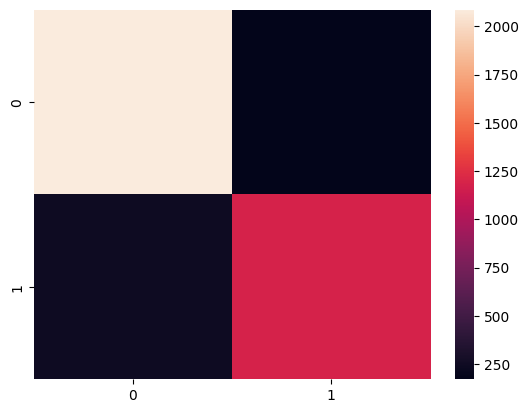

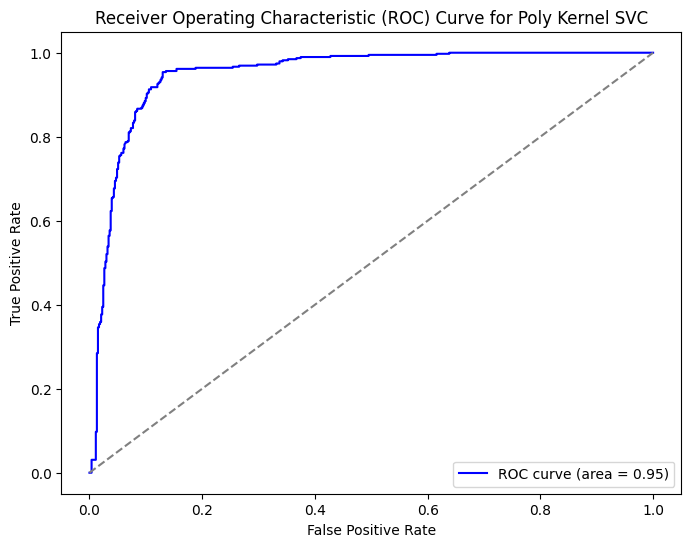


----- Fold ------

Accuracy Score of Testing  : 0.8782608695652174
Precision Score of Testing : 0.8551136363636364
F1 Score of Testing        : 0.8431372549019608
Recall Score of Testing    : 0.8314917127071824

Confusion Matrix :- 
 [[2089  141]
 [ 234 1217]]


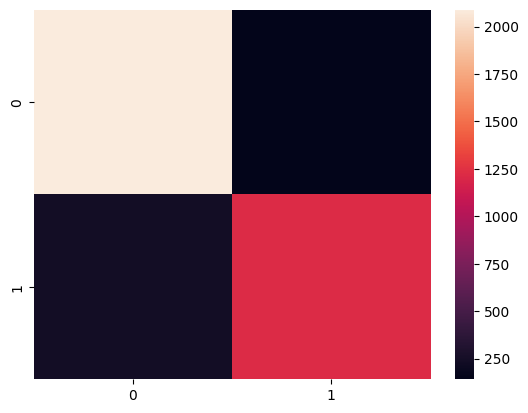

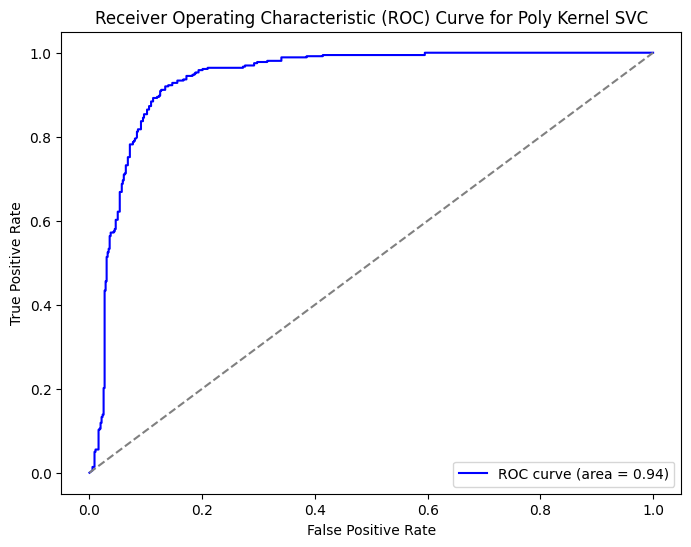


----- Fold ------

Accuracy Score of Testing  : 0.8978260869565218
Precision Score of Testing : 0.8987730061349694
F1 Score of Testing        : 0.861764705882353
Recall Score of Testing    : 0.827683615819209

Confusion Matrix :- 
 [[2062  160]
 [ 229 1230]]


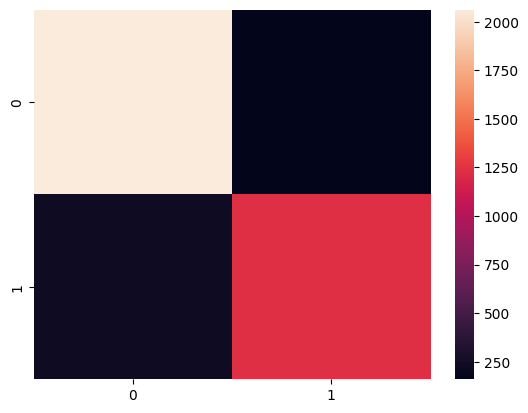

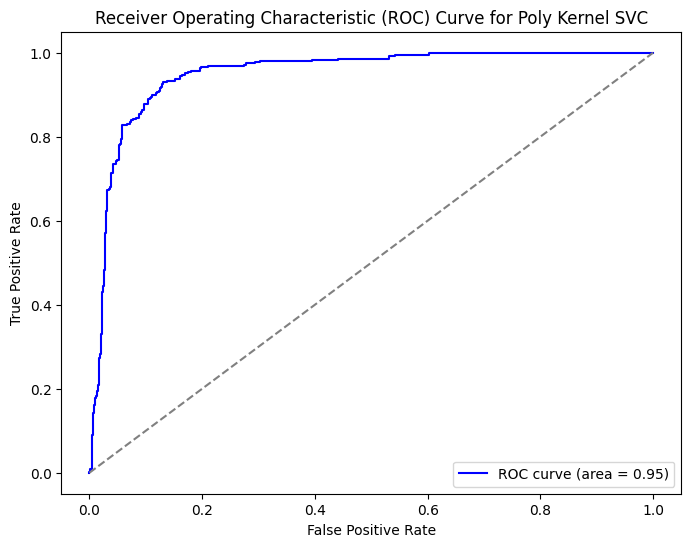


----- Fold ------

Accuracy Score of Testing  : 0.9010869565217391
Precision Score of Testing : 0.8768328445747801
F1 Score of Testing        : 0.8679245283018868
Recall Score of Testing    : 0.8591954022988506

Confusion Matrix :- 
 [[2053  163]
 [ 230 1235]]


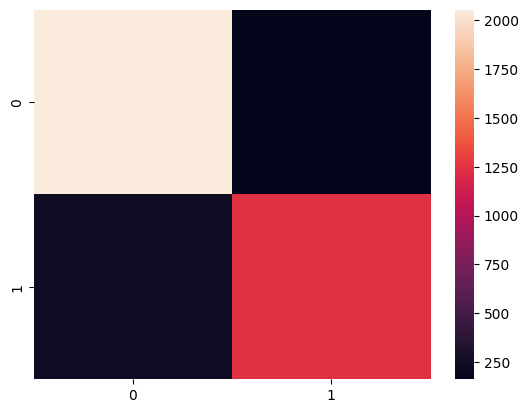

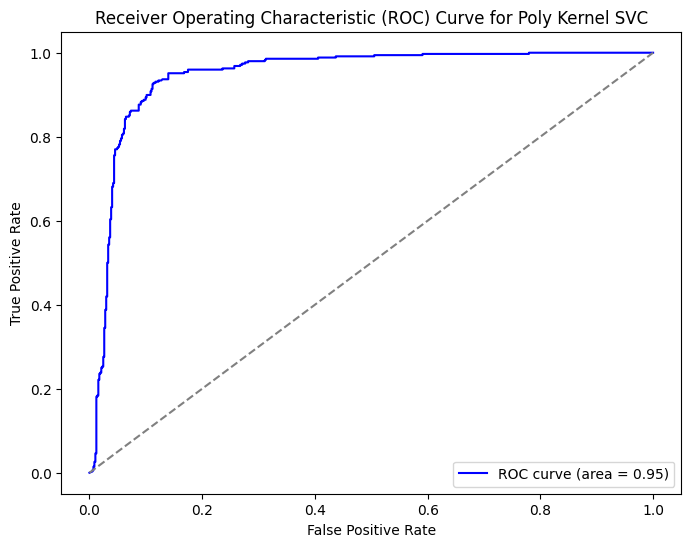


----- Fold ------

Accuracy Score of Testing  : 0.8967391304347826
Precision Score of Testing : 0.9
F1 Score of Testing        : 0.8621190130624092
Recall Score of Testing    : 0.8272980501392758

Confusion Matrix :- 
 [[2073  154]
 [ 230 1224]]


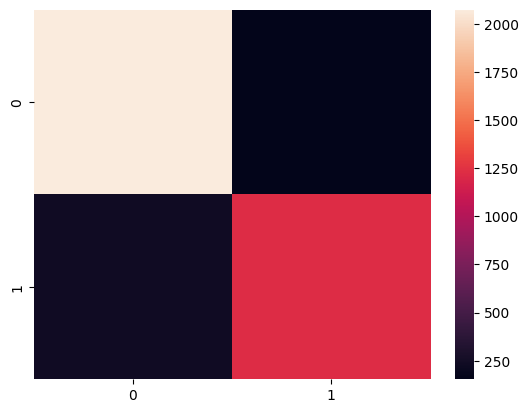

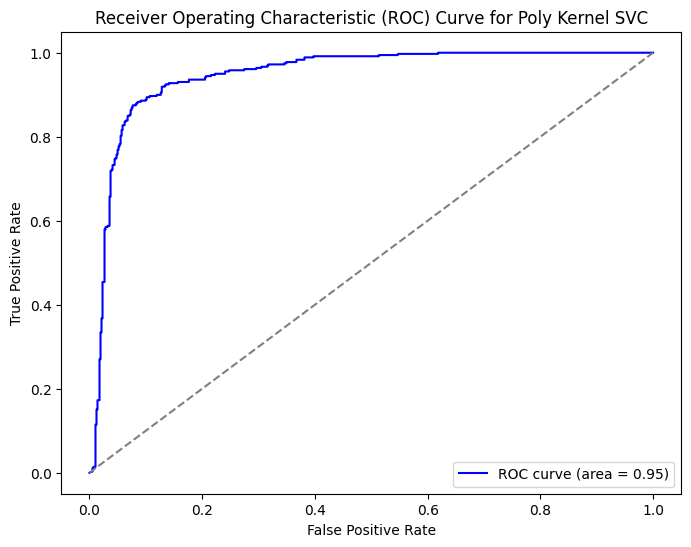

In [28]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = SVC(kernel= 'sigmoid', gamma= 1.0, C= 10,probability = True)
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)'''

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]
  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)
  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for Poly Kernel SVC')
  plt.legend(loc='lower right')
  plt.show()


In [29]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for Sigmoid Kernel SVC :-\n")
df

K Fold for Sigmoid Kernel SVC :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.883822,0.887671,0.858278,0.830769,0.948474
1,2,0.878261,0.855114,0.843137,0.831492,0.938719
2,3,0.897826,0.898773,0.861765,0.827684,0.948389
3,4,0.901087,0.876833,0.867925,0.859195,0.947357
4,5,0.896739,0.900000,0.862119,0.827298,0.946611
5,Mean,0.891547,0.883678,0.858645,0.835288,0.945910


**(iv) Linear Kernel**


----- Fold ------

Accuracy Score of Testing  : 0.9174809989142236
Precision Score of Testing : 0.9337016574585635
F1 Score of Testing        : 0.898936170212766
Recall Score of Testing    : 0.8666666666666667

Confusion Matrix :- 
 [[2158   99]
 [ 171 1252]]


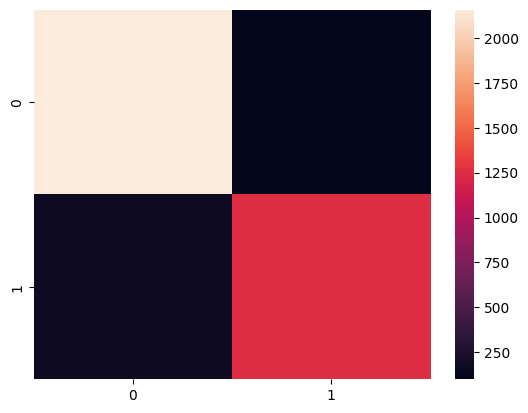

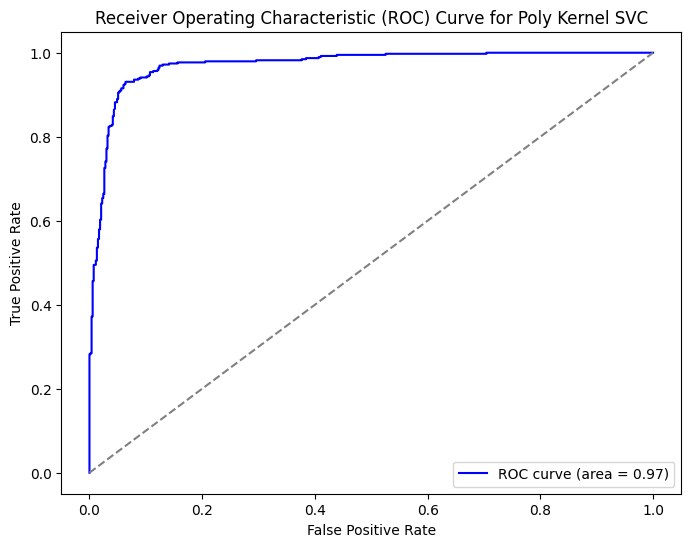


----- Fold ------

Accuracy Score of Testing  : 0.9239130434782609
Precision Score of Testing : 0.9101123595505618
F1 Score of Testing        : 0.9025069637883009
Recall Score of Testing    : 0.8950276243093923

Confusion Matrix :- 
 [[2138   92]
 [ 163 1288]]


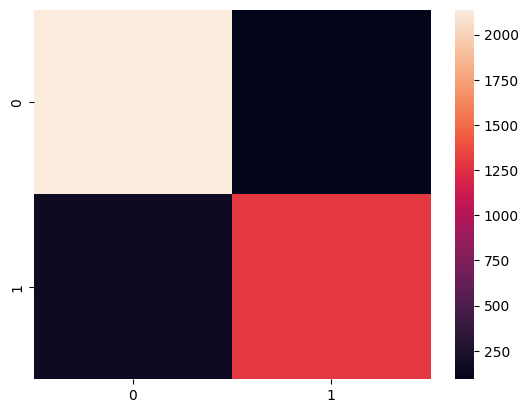

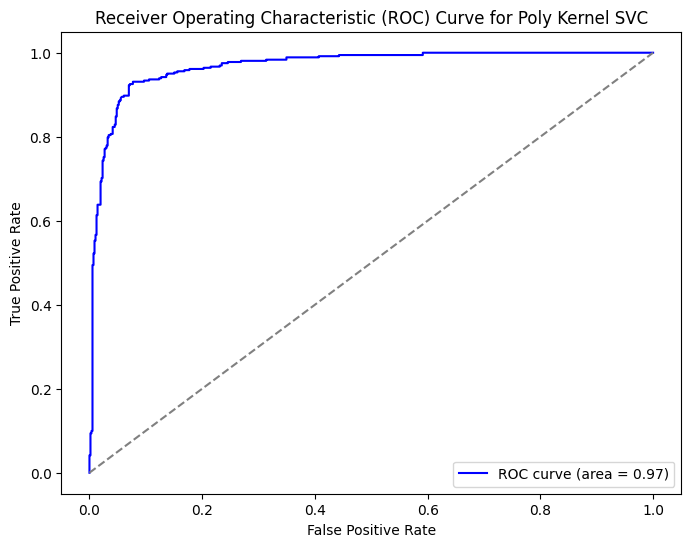


----- Fold ------

Accuracy Score of Testing  : 0.9195652173913044
Precision Score of Testing : 0.9166666666666666
F1 Score of Testing        : 0.8927536231884058
Recall Score of Testing    : 0.8700564971751412

Confusion Matrix :- 
 [[2130   92]
 [ 169 1290]]


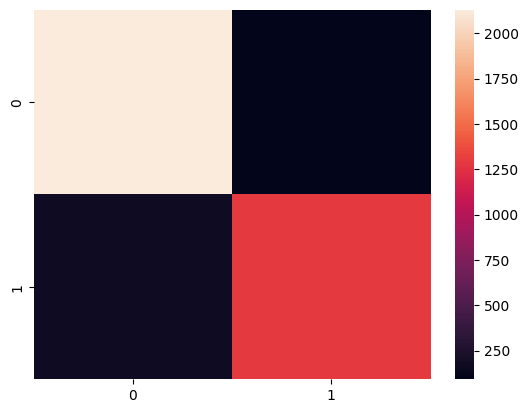

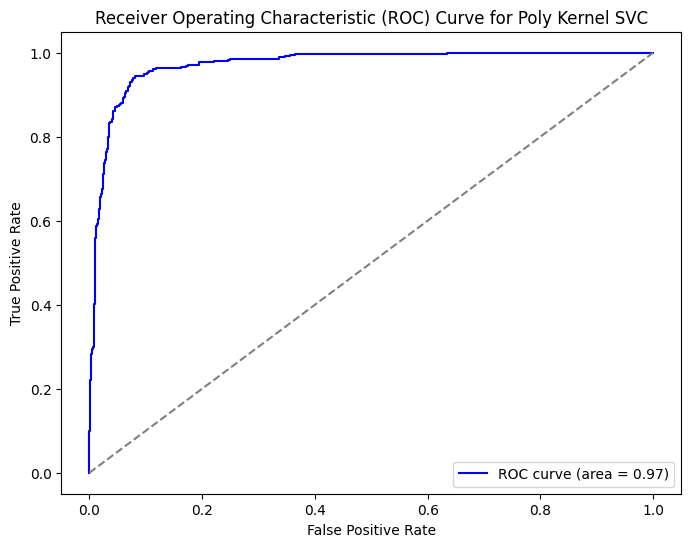


----- Fold ------

Accuracy Score of Testing  : 0.9315217391304348
Precision Score of Testing : 0.9130434782608695
F1 Score of Testing        : 0.9090909090909091
Recall Score of Testing    : 0.9051724137931034

Confusion Matrix :- 
 [[2120   96]
 [ 173 1292]]


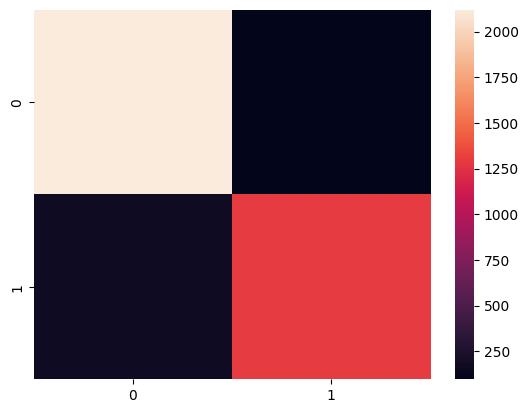

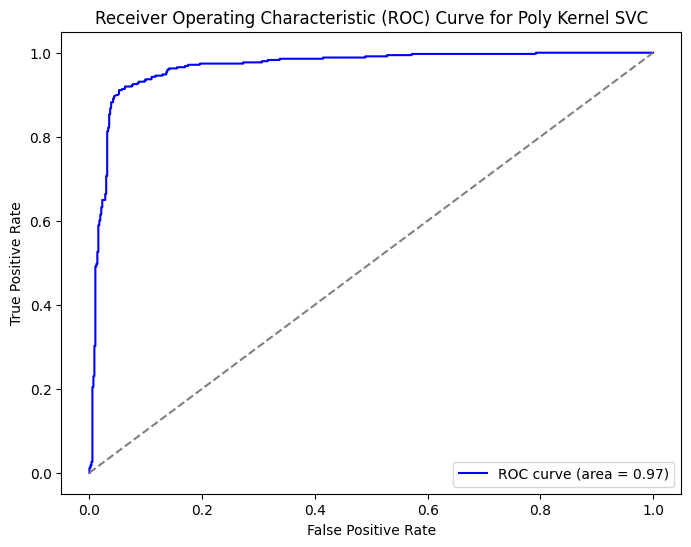


----- Fold ------

Accuracy Score of Testing  : 0.9282608695652174
Precision Score of Testing : 0.9425981873111783
F1 Score of Testing        : 0.9043478260869565
Recall Score of Testing    : 0.8690807799442897

Confusion Matrix :- 
 [[2126  101]
 [ 166 1288]]


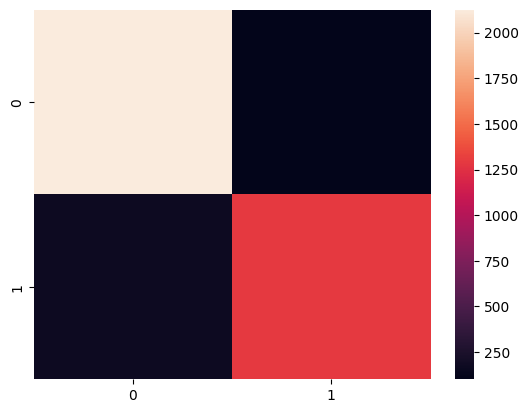

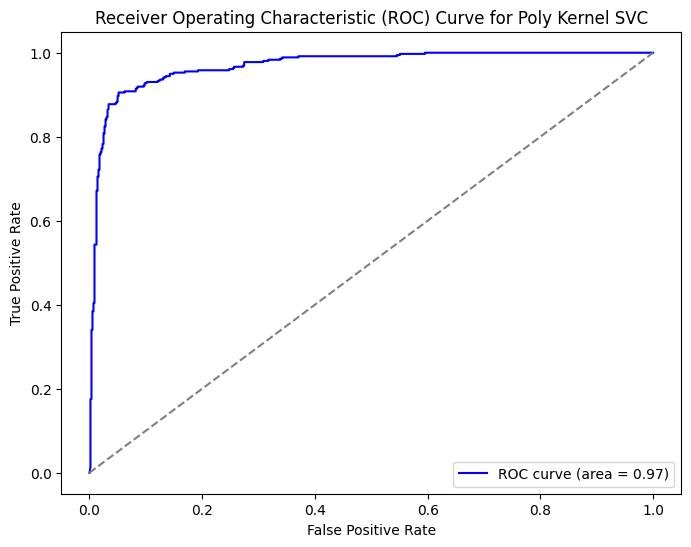

In [30]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = SVC(C= 10, kernel= 'linear',probability = True)
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  #sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  '''print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)'''

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]

  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)

  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for Poly Kernel SVC')
  plt.legend(loc='lower right')
  plt.show()

In [31]:
# @title
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for Linear Kernel SVC :-\n")
df

K Fold for Linear Kernel SVC :-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.917481,0.933702,0.898936,0.866667,0.971261
1,2,0.923913,0.910112,0.902507,0.895028,0.968210
2,3,0.919565,0.916667,0.892754,0.870056,0.971332
3,4,0.931522,0.913043,0.909091,0.905172,0.965753
4,5,0.928261,0.942598,0.904348,0.869081,0.969081
5,Mean,0.924148,0.923224,0.901527,0.881201,0.969128
